### 1 - Introduction


In [68]:
########################################## Cell 0: Import (un)necessary packages ############################################

#%pip install pandas numpy scipy matplotlib torch torchvision torchaudio scikit-learn

import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D
import pandas as pd
import torch
import csv
from datetime import datetime
from pathlib import Path
import statistics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import random
from collections import Counter
from sklearn.metrics import r2_score
import requests
import os
import fnmatch

random.seed(42)
np.random.seed(42)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

REPO = "leogundersen/ESACT2026_Hybrid_Modelling"
BRANCH = "main"
RAW_BASE = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}"

def get_repo_file_list():
    url = f"https://api.github.com/repos/{REPO}/git/trees/{BRANCH}?recursive=1"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return [item["path"] for item in resp.json()["tree"] if item["type"] == "blob"]

REPO_FILES = get_repo_file_list()
EXCEL_DIR = f"{RAW_BASE}/Excel"          # reading only

LOCAL_OUTPUT_DIR = r"C:\Users\SBEGroup\Desktop\ESACT2026_Hybrid_Modelling\Excel"
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

#To generate new data, change to True
Generate_new_data = False 

#LGnote: 
#dfcoefs contains stoichiometric coefficients and dfinfo contains mAb info and vmaxmab values.
#In this version, when Generate_new_data = False, only vmaxmab values are used. Other values can be used to calculate new
#   vmaxmab values, as seen in Section 2, allowing for the generation of new vmaxmab values and the correspondent coefficents. 
# Additionaly, new mAbs can be added, provided the new mAb sequence is saved in the excel dfinfo. 

In [69]:
##################################### Cell 1A: Extract mAb information from excel files ########################################

#file with kinetic coeffients for ODE (atp_value, a_value, etc.)
dfcoefs = pd.read_csv(f"{EXCEL_DIR}/coefs_LG_final.csv", index_col=False)

#file with ChemEMBL ID, light and Heavy Chain sequence, Combined sequence, IEEE754, standardized_values, p value, vmaxmab value)
dfinfo = pd.read_csv(f"{EXCEL_DIR}/mAB_info_LG_final.csv", index_col=False)

#a and b values can serve to provide a range of mAbs to analyse, but otherwise serve no purpose.
a = 0
b = 71

#extract list of mAb names (ensure it matches the 72 mAbs in the excel)
mabnames_list = dfinfo['Name'].iloc[:].tolist()
print(mabnames_list)
print(len(mabnames_list))

['satralizumab', 'naxitamab', 'emicizumab', 'ravulizumab', 'secukinumab', 'Adalimumab', 'Bamlanivimab', 'atoltivimab', 'anifrolumab', 'enfortumab', 'sacituzumab', 'crizanlizumab', 'ipilimumab', 'brodalumab', 'guselkumab', 'amivantamab', 'belantamab', 'idarucizumab', 'maftivimab', 'polatuzumab', 'obinutuzumab', 'margetuximab', 'imdevimab)', 'tafasitamab', 'necitumumab', 'sarilumab', 'arcitumomab', 'vedolizumab', 'daratumumab', 'siltuximab', 'faricimab', 'elotuzumab', 'romosozumab', 'Bebtelovimab', 'cilgavimab', 'galcanezumab', 'casirivimab', 'ramucirumab', 'alemtuzumab', 'tralokinumab', 'isatuximab', 'avelumab', 'sutimlimab', 'bimekizumab', 'mogamulizumab', 'teprotumumab', 'tisotumab', 'cemiplimab', 'lanadelumab', 'relatlimab', 'ibalizumab', 'risankizumab', 'mosunetuzumab', 'ansuvimab', 'fremanezumab', 'Obiltoxaximab', 'eptinezumab', 'basiliximab', 'bezlotoxumab', 'odesivimab', 'emapalumab', 'benralizumab', 'evinacumab', 'burosumab', 'tezepelumab', 'ixekizumab', 'erenumab', 'durvalumab'

In [70]:
##################################### Cell 1B: Establish DoE ########################################

#establish DoE framework (Central Composite design)
doedf = pd.DataFrame(columns=['T_ind', 'Feed_pre_ind', 'Feed_post_ind'])

doedf.loc[len(doedf)] = ['72','0.20','1.50']            #Diamond

doedf.loc[len(doedf)] = ['84', '0.081', '0.608']         #Cube
doedf.loc[len(doedf)] = ['84', '0.081', '2.392']        #Cube
doedf.loc[len(doedf)] = ['84', '0.319', '0.608']         #Cube
doedf.loc[len(doedf)] = ['84', '0.319', '2.392']        #Cube

doedf.loc[len(doedf)] = ['96', '0.0', '1.50']          #Diamond
doedf.loc[len(doedf)] = ['96', '0.40', '1.50']          #Diamond
doedf.loc[len(doedf)] = ['96', '0.20', '0.0']           #Diamond#
doedf.loc[len(doedf)] = ['96', '0.20', '3.00']          #CENTER
doedf.loc[len(doedf)] = ['96', '0.20', '1.50']          #Diamond

doedf.loc[len(doedf)] = ['108', '0.081', '0.608']        #Cube
doedf.loc[len(doedf)] = ['108', '0.081', '2.392']       #Cube
doedf.loc[len(doedf)] = ['108', '0.319', '0.608']        #Cube
doedf.loc[len(doedf)] = ['108', '0.319', '2.392']       #Cube

doedf.loc[len(doedf)] = ['120', '0.20', '1.50']      #Diamond

### 2- Generate vmaxmab and mAb coefficients

In [71]:
############################## Cell 2A: Convert mAb sequence into single number (IEEE754) ############################################

#LGnote: This entire section is redundant when Generated_new_data = False. In this section, the sequence (saved in the excel) is 
#           used to generate a unique number ("IEEE754"), Cell 2A. This number is then used to obtain a standardized value, in 
#           Cell 2B, which considers a separation between above and below average mAbs. These values are used in a logistic regression 
#           (Cell 2C) to calculate standardized p values (Cell 2D) which are distributed in a sigmoid shape. Finally, these values are
#           applied to generate new vmaxmab values (Cell 2E). Note that some randomness is included in the generation of vmaxmab, and
#           therefore reruning this twice will generate different results!            
#         Additionally, the stoichiometric coeffients are calculated for each mAb (Cell 2G), and used in data generation.

#convert protein sequences into a unique "numeric fingerprint" for each mAb. 
def amino_acid_to_ieee754(amino_acid_sequence):
    #define the mapping of amino acids to binary strings
    amino_acid_mapping = {
        'A': '00000',  # Alanine
        'C': '00001',  # Cysteine
        'D': '00010',  # Aspartic acid
        'E': '00011',  # Glutamic acid
        'F': '00100',  # Phenylalanine
        'G': '00101',  # Glycine
        'H': '00110',  # Histidine
        'I': '00111',  # Isoleucine
        'K': '01000',  # Lysine
        'L': '01001',  # Leucine
        'M': '01010',  # Methionine
        'N': '01011',  # Asparagine
        'P': '01100',  # Proline
        'Q': '01101',  # Glutamine
        'R': '01110',  # Arginine
        'S': '01111',  # Serine
        'T': '10000',  # Threonine
        'V': '10001',  # Valine
        'W': '10010',  # Tryptophan
        'Y': '10011',  # Tyrosine
        'X': '10100'   # Unknown or any other amino acid
    }

    #function to pad the sequence with 'X' until its length is a multiple of 12
    def pad_sequence(sequence, multiple=12):
        while len(sequence) % multiple != 0:
            sequence += 'X'
        return sequence

    #pad the amino acid sequence
    amino_acid_sequence = pad_sequence(amino_acid_sequence)

    #function to split the sequence into parts of length 12
    def split_sequence(sequence, part_length=12):
        return [sequence[i:i + part_length] for i in range(0, len(sequence), part_length)]

    #split the amino acid sequence
    parts = split_sequence(amino_acid_sequence)

    #initialize total sum
    total_value = 0  
    for part in parts:
        if len(part) != 12:
            raise ValueError("Amino acid sequence must be exactly 12 characters long.")

        #convert the amino acid sequence to a binary string (12*5 = 60)
        binary_string = '0000' + ''.join(amino_acid_mapping[aa] for aa in part)

        #ensure the binary string is exactly 64 bits
        if len(binary_string) != 64:
            raise ValueError("The binary string must be exactly 64 bits long.")

        #IEEE 754 components
        sign = int(binary_string[0], 2)     # 1 bit
        exponent_bits = binary_string[1:12] # 11 bits
        mantissa_bits = binary_string[12:]  # 52 bits

        #calculate the exponent
        exponent = int(exponent_bits, 2) - 1023  # Subtract the bias (1023)

        #calculate the mantissa
        mantissa = 1  #implicit leading 1
        for i, bit in enumerate(mantissa_bits):
            mantissa += int(bit) * (2 ** -(i + 1))

        #calculate the final value
        value = (-1) ** sign * mantissa * (2 ** exponent)
        total_value += value  #add to total sum

    return total_value

#generate "IEEE754" values for each mAb
dfinfo['IEEE754'] = dfinfo['Combined Chains'].apply(amino_acid_to_ieee754)

#ensure uniqueness
dfinfo['IEEE754'].is_unique

True

In [72]:
############################## Cell 2B: Generate and standardize IEEE754 values ############################################

values= dfinfo['IEEE754'].tolist()

#scaling factor is used to improve stability of IEEE754
scaling_factor = 10**263

#scale the IEEE754
scaled_values = [value * scaling_factor for value in values]

#standardizing the values
mean = statistics.mean(scaled_values)
stdev = statistics.stdev(scaled_values)

standardized_values = [(x - mean) / stdev for x in scaled_values]

#generate "standardize values"
dfinfo['standardized_values'] = standardized_values

#since values are standardized, mean = 0
threshold = 0

#create a dictionary to assign 0 or 1 based on the threshold (below/above average values)
value_dict = {value: (0 if value < threshold else 1) for value in standardized_values}

#count the number of values below the threshold
count_below_threshold = sum(1 for value in standardized_values if value < threshold)

In [73]:
############################## Cell 2C: Generate and standardize IEEE754 values ############################################

#prepare the feature set (X) and target variable (y)
X = np.array(list(value_dict.keys())).reshape(-1, 1)    #standardized values
y = np.array(list(value_dict.values()))                 #0 or 1 for below/above standardized values

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

#get coefficients
coef = model.coef_[0][0]
intercept = model.intercept_[0]

#define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#create a range of x values
x_vals = np.linspace(X.min(), X.max(), 300)
logit_vals = intercept + coef * x_vals
prob_vals = sigmoid(logit_vals)

The equation for $ p $ is given by:


$$p = \frac{1}{1 + e^{-({b_0} + {b} \cdot aa)}}$$


Where:
- ${b_0}=-0.584$ is the intercept value.
- ${b=2.912}$ is the coefficient for $ x $.

C:\Users\SBEGroup\AppData\Local\Temp\ipykernel_34752\1592348474.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-(intercept + coef * x1)))


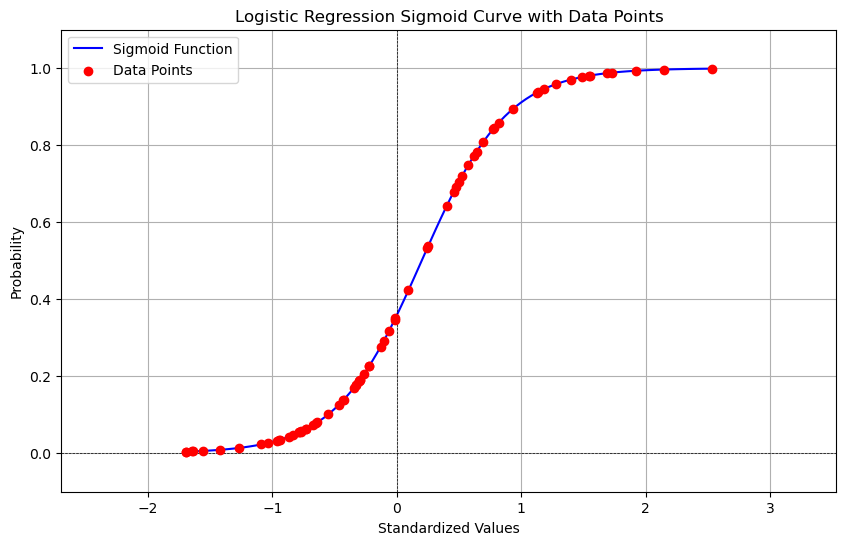

In [74]:
############################## Cell 2D: Generate and standardize IEEE754 values ############################################

#function to calculate p
def calculate_p(x1):
    return 1 / (1 + math.exp(-(intercept + coef * x1)))

#apply the function to the 'standardized values' column and create a new column 'p'
dfinfo['p'] = dfinfo['standardized_values'].apply(calculate_p)

#generate a range of values for plotting the sigmoid curve
x_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_prob = np.array([calculate_p(x) for x in x_range]) 

new_y = dfinfo['p']

#plotting the sigmoid function and the points
plt.figure(figsize=(10, 6))
plt.plot(x_range, y_prob, label='Sigmoid Function', color='blue')
plt.scatter(X, new_y, color='red', label='Data Points', zorder=5)
plt.title('Logistic Regression Sigmoid Curve with Data Points')
plt.xlabel('Standardized Values')
plt.ylabel('Probability')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid()
plt.legend()
plt.xlim(min(X) - 1, max(X) + 1)
plt.ylim(-0.1, 1.1)
plt.show()

$$V_{\text{maxmab}} = V_{\text{min}} \times \left(1 + 0.1 \times random\_float\right) + 10 \times V_{\text{min}} \times \frac{1}{1 + e^{-(b_0 + b \cdot aa)}}$$

where 

$$\text{random\_float} \sim \text{Uniform}(10, 20)$$

In [75]:
################################ Cell 2E: Generate new vmaxmab values  ############################################

if Generate_new_data:

    dfinfo['vmaxmab'] = 0
    Vmin = 0.005

    for index, row in dfinfo.iterrows():
        start = row['IEEE754']
        p = row['p']
        
        mab_feature = start * 10**263

        random_float = random.uniform(10, 20)

        standardized_mab_feature = (mab_feature - mean) / stdev

        X = np.array([[standardized_mab_feature]])

        #vmaxmab = round(Vmin*(1 + 0.1*random_float) + 10*Vmin*model.predict(X)[0], 6)
        vmaxmab = round(Vmin*(1 + 0.1*random_float) + 10*Vmin*p, 6)

        dfinfo.at[index, 'vmaxmab'] = float(vmaxmab)

    #overwrite file with newly generated values
    dfinfo.to_csv(os.path.join(LOCAL_OUTPUT_DIR, "mAB_info_LG_final.csv"), index=False)
    print("New vmaxmab values generated and saved locally.")

else:
    #use already saved data in excel files
    dfinfo = pd.read_csv(f"{EXCEL_DIR}/mAB_info_LG_final.csv", index_col=False)  # remote, unchanged
    print("Using existing vmaxmab values from the repo.")

Using existing vmaxmab values from the repo.


In [76]:
################################ Cell 2F: Prepare coefficient generation  ############################################

tabulated_MW = {
    'A': 89.093,   # Alanine
    'C': 121.158,  # Cysteine
    'D': 133.104,  # Aspartic Acid
    'E': 147.131,  # Glutamic Acid
    'F': 165.192,  # Phenylalanine
    'G': 75.067,   # Glycine
    'H': 155.156,  # Histidine
    'I': 131.174,  # Isoleucine
    'K': 146.189,  # Lysine
    'L': 131.174,  # Leucine
    'M': 149.207,  # Methionine
    'N': 132.119,  # Asparagine
    'P': 115.132,  # Proline
    'Q': 146.146,  # Glutamine
    'R': 174.203,  # Arginine
    'S': 105.093,  # Serine
    'T': 119.119,  # Threonine
    'V': 117.148,  # Valine
    'W': 204.228,  # Tryptophan
    'Y': 181.191,  # Tyrosine
}

#function to count amino acids
def count_amino_acids(sequence):
    if pd.isna(sequence):  # Check if the sequence is NaN or None
        return {}  # Return an empty dictionary if it is
    return dict(Counter(sequence))

#function to calculate weighted counts
def calculate_weighted_counts(counts, mw_dict):
    weighted_counts = {}
    for amino_acid, count in counts.items():
        if amino_acid in mw_dict:
            weighted_counts[amino_acid] = count * mw_dict[amino_acid]
    return weighted_counts

In [77]:
################################ Cell 2G: Generate new coefficient values  ############################################

results = []
columns = ['Name', 'ATP', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

#iterate over each row in the DataFrame
if Generate_new_data:
    for index, row in dfinfo.iterrows():
        name = row['Name']

        #count each aminoacid, count = mmol/mmol of IgG
        light_chain_counts = count_amino_acids(row['Light Chain'])
        heavy_chain_counts = count_amino_acids(row['Heavy Chain'])

        total_light_chain_count = sum(light_chain_counts.values())
        total_heavy_chain_count = sum(heavy_chain_counts.values())

        #count the waters released when bonds form (heavy_count_sum-light_count_sum)
        delete_waters = -(total_light_chain_count + total_heavy_chain_count) * 18.01528

        #calculate weighted counts for light and heavy chains, multiply the tabulated MW of each aminoacid and sum it all
        light_chain_weighted = calculate_weighted_counts(light_chain_counts, tabulated_MW)
        heavy_chain_weighted = calculate_weighted_counts(heavy_chain_counts, tabulated_MW)

        #igg MW g/mol
        igg_mw = (sum(light_chain_weighted.values()) + sum(heavy_chain_weighted.values()) + delete_waters) * 2
        
        #divide each aminoacid count by the igg MW g/mol to get the ODEs coefs
        mmolg = {key: value / igg_mw for key, value in light_chain_counts.items()}

        #create a new row for the results
        data = {col: mmolg.get(col, None) for col in columns[2:]}  # Get values from mmolg or None if not present
        data['Name'] = name  # Set the Name

        results.append(data)

        #ATPs
        if igg_mw!=0:
            ampcoef=((total_light_chain_count+total_heavy_chain_count)*2)/igg_mw
            gdpcoef=(((total_light_chain_count+total_heavy_chain_count)*4)-8)/igg_mw
            adpcoef=4/igg_mw
            data['ATP'] = ampcoef+gdpcoef+adpcoef

    #populate the DataFrame with the results
    dfcoefs = pd.DataFrame(results, columns=columns)
    
    dfcoefs.to_csv(LOCAL_OUTPUT_DIR, "coefs_LG_final.csv")
    print("New coefficient values generated and saved.")

else:
    #use already saved data in excel files
    dfcoefs = pd.read_csv(f"{EXCEL_DIR}/coefs_LG_final.csv", index_col=False)  # remote, unchanged
    print("Using existing coefficient values from the repo.")

Using existing coefficient values from the repo.


### 3 - Kinetics (retrive from Pinto et al. (2022))

In [78]:
######################################### Cell 3A: Define kinetic constants, kinetic equations, growth ############################################

def kinetics(X, mAB, ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL,
             ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, V, t, upars):
    
######################################################### Kinetic constants ##################################################################

     #These values were based on the paper Robitaille et al. (2015): “A Single Dynamic Metabolic Model Can Describe mAb Producing CHO Cell Batch and Fed-Batch Cultures on Different Culture Media,”,
          #but were adapted by J. Pinto to the datasets provided by JSK (previous work).

     #constants
     aAMP = 0.47
     aF6P = 4.1
     bAMP = 10.46
     bF6P = 1.7
     KAAMP = 0.09

     KAF6P = 4.9e-6 / 3.15e-04

     #half-saturation constants
     KdCIT = 7.4e-4  / 3.15e-04
     KdEGLN = 3.5
     KdG6P = 1.710841e-8  / 3.15e-04
     KdLAC = 6.3 
     KdPEP = 3.7e-7  / 3.15e-04
     KdPYR = 4.5e-7  / 3.15e-04
     KdLACg = 170
     KdNH4g = 5.40

     KdALA = 0.1  #mM (Missing from S4)
     
     KmACCOA = 8.6e-7  / 3.15e-04
     KmADP = 7.2e-7  / 3.15e-04
     KmAKG = 1.1e-6  / 3.15e-04
     KmALA = 18
     KmAMP = 2.4e-9  / 3.15e-04
     KmARG = 7.3e-2
     KmASP = 4e-2
     KmASN = 1.2
     KmATP = 1.56e-5  / 3.15e-04
     KmCIT = 1.6e-7  / 3.15e-04
     KmEGLC = 20
     KmEGLN = 2.3
     KmEGLU = 6.6
     KmF6P = 2.6e-6  / 3.15e-04
     KmG6P = 2.866e-8  / 3.15e-04
     KmGAP = 7.8e-7  / 3.15e-04
     KmGLU = 7.5e-5  / 3.15e-04
     KmGLY = 5e-2  #/ 3.15e-04
     KmHIS = 0.58
     KmILE = 0.038
     KmLAC = 2.9
     KmLEU = 1e-6
     KmLYS = 9.8e-2
     KmMAL = 2.7e-6  / 3.15e-04
     KmNADH = 2.6e-6  / 3.15e-04
     KmNADPH = 8.4e-8  / 3.15e-04
     KmNH4 = 1.1
     KmOXA = 2.2e-7  / 3.15e-04
     KmPEP = 1.7e-7  / 3.15e-04
     KmPYR = 3.9e-6  / 3.15e-04
     KmR5P = 7e-8  / 3.15e-04
     KmSER = 0.22
     KmSUC = 2.3e-7  / 3.15e-04
     KmTYR = 4.8e-2
     KmVAL = 1
     KmX5P = 1.1e-8  / 3.15e-04

     #maximal velocities
     Pratio = 2.1

     VfmaxAK = 1.8e-8  / 3.15e-04
     VrmaxAK = 1.2e-8  / 3.15e-04
     VmaxAKGDH = 2.6e-4  / 3.15e-04
     VfmaxALATA = 1.7e-4  / 3.15e-04
     VrmaxALATA = 2.4e-4  / 3.15e-04
     VmaxASN = 6.2e-6  / 3.15e-04
     VmaxASTA = 7.8e-5  / 3.15e-04
     VmaxATPASE = 9.14e-4  / 3.15e-04
     VmaxCITS = 3.9e-5  / 3.15e-04
     VmaxCS = 8.8e-5  / 3.15e-04
     VmaxEP = 1.3e-5  / 3.15e-04
     VmaxG6PDH = 1.5e-5  / 3.15e-04
     VfmaxGLDH = 1.2e-6  / 3.15e-04
     VrmaxGLDH = 6.3e-5  / 3.15e-04
     VfmaxGLNT = 1.27e-4  / 3.15e-04
     VrmaxGLNT = 1.9e-5  / 3.15e-04
     VfmaxGLUT = 1.8e-6  / 3.15e-04
     VrmaxGLUT = 2.5e-6  / 3.15e-04

     Vmaxgrowth = 6.6e-2

     VmaxHISARGTA = 1.9e-5  / 3.15e-04
     VmaxHK = 6.6e-4  / 3.15e-04
     VfmaxLDH = 1.7e-3  / 3.15e-04
     VrmaxLDH = 5.4e-4  / 3.15e-04
     Vmaxleak = 2.9e-5  / 3.15e-04
     VmaxAATOSUC = 1.3e-4  / 3.15e-04
     VmaxMAB = upars[3]  / 3.15e-04 ##upars[3] = VmaxMAB (See Cell 4A)
     VmaxME = 1.3e-5  / 3.15e-04
     VmaxMLD = 9.5e-5  / 3.15e-04
     VmaxNADPHOX = 1.4e-5  / 3.15e-04
     VmaxPC = 2.1e-4  / 3.15e-04
     VmaxPDH = 7.1e-4  / 3.15e-04
     VmaxPFK = 1.5e-3  / 3.15e-04
     VfmaxPGI = 7.6e-4  / 3.15e-04
     VrmaxPGI = 3.5e-4  / 3.15e-04
     VmaxPGK = 1.065e-3  / 3.15e-04
     VmaxPK = 1.376e-3  / 3.15e-04
     VmaxPPRIBP = 2.6e-9  / 3.15e-04
     Vmaxresp = 0.0032  / 3.15e-04
     VmaxSDH = 4e-4  / 3.15e-04
     VmaxSDHH = 8.5e-6  / 3.15e-04
     VmaxTK = 2.3e-5  / 3.15e-04

     #half-saturation constants
     KmALAg = 7.6e-2 #mM
     KmARGg = 1.5e-2 #mM
     KmASNg = 4.2e-3  #mM
     KmASPg = 1e-2  #mM
     KmATPg = 1.4e-7 / 3.15e-04 #mmol.gDW-1
     KmCITg = 3.5e-9  / 3.15e-04  #mmol.gDW-1
     KmCYSg = 1e-3 #mM
     KmEGLNg = 1.4e-3 #mM
     KmG6Pg = 9.9e-13  / 3.15e-04 #mmol.gDW-1
     KmEGLUg = 1.7e-6  #/ 3.15e-04 #mmol.gDW-1 #mM 
     KmGLUg = 1.7e-6 / 3.15e-04 #mM   #LGNote: Changed here 0903
     KmGLYg = 1e-2 #mM
     KmHISg = 1.7e-2 #mM
     KmILEg = 1e-2 #mM
     KmLYSg = 2.7e-2 #mM
     KmMETg = 3.5e-2 #mM
     KmPHEg = 1.6e-2 #mM
     KmPROg = 1e-2 #mM
     KmR5Pg = 1.1e-10 / 3.15e-04 #mmol.gDW-1
     KmSERg = 1.1e-3 #mM
     KmTHRg = 9.6e-3 #mM
     KmTYRg = 1.2e-2 #mM
     KmVALg = 1.3e-3 #mM

     KmALAMAB = 0.13 #mM
     KmARGMAB = 6.2e-2 #mM
     KmASNMAB = 1.4e-6 #mM
     KmASPMAB = 5.6e-2 #mM
     KmATPMAB = 1.1e-7 / 3.15e-04 #mmol.gDW-1
     KmCYSMAB = 1e-3 #mM
     KmEGLNMAB = 1.3e-3 #mM
     KmEGLUMAB = 0.22 #/ 3.15e-04 #mmol.gDW-1 #mM 
     KmGLUMAB = 1.7e-6 / 3.15e-04    #LGNote: Changed here 0903
     KmGLYMAB = 5e-2 #mM
     KmHISMAB = 5.7e-2 #mM
     KmILEMAB = 8.3e-2 #mM
     KmLEUMAB = 1e-6  #mM
     KmLYSMAB = 5e-2 #mM
     KmMETMAB = 8e-2 #mM
     KmPHEMAB = 7.1e-2 #mM
     KmPROMAB = 1.1e-2 #mM
     KmSERMAB = 1e-3 #mM
     KmTHRMAB = 6.6e-2 #mM
     KmTYRMAB = 9.8e-2 #mM
     KmVALMAB = 7.4e-2 #mM
     KmADPATP = 0.569423 
     KmATPADP = 0.091 
     KmNADNADH = 4.8e-2 
     KmNADHNAD = 0.3 
     KmNADPNADPH = 2 

     kdMin= 2.6e-6  #h-1
     kdMax= 3.3e-3  #h-1
     BB = 1e-3  #h-1
     K_bNAD= 1e-5 / 3.15e-04
     keq_NAD= 1e-5 / 3.15e-04
     K_bAMP= 1e-5 / 3.15e-04
     keq_AMP= 1e-4 / 3.15e-04
     K_bNADP= 1e-5 / 3.15e-04
     keq_NADP= 1e-5 / 3.15e-04
     keq_AK= 10 #/ 3.15e-04
     km_AK= 1e-6 / 3.15e-04
     VrmaxTHDR= 2e-7 / 3.15e-04 #mmol.gDW-1.h-1
     km_THDR= 1 #/ 3.15e-04 LGnote Fix units
     Km_TYR_VAA= 2 #/ 3.15e-04 LGnote Fix units
     vrmaxPYRT= 3e-6 / 3.15e-04 #mmol.gDW-1.h-1
     k_EPYR= 5e-3 
     k_PYR= 4e-7 / 3.15e-04 

######################################################### Kinetic equations ##################################################################

     #rate equations
     # Hexokinase
     e1 = EGLC * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmEGLC * (1 + (AMP / ATP) / KAAMP)
     e3 = EGLC * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (ATP / ADP) / (KmATPADP + (ATP / ADP))
     e5 = EGLC / (KmEGLC + EGLC)
     e6 = KdG6P / (KdG6P + G6P)
     VHK = VmaxHK * (e1 / (e2 + e3)) * e4 * e5 * e6

     # Phosphoglucose isomerase
     VPGI = VfmaxPGI * (G6P / (KmG6P + G6P)) * (KdPEP / (KdPEP + PEP)) - VrmaxPGI * (F6P / (KmF6P + F6P))

     # Phosphofructokinase
     e1 = F6P * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmF6P * (1 + (AMP / ATP) / KAAMP)
     e3 = F6P * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (ATP / ADP) / (KmATPADP + (ATP / ADP))
     e5 = KdLAC / (KdLAC + LAC)
     VPFK = VmaxPFK * (e1 / (e2 + e3)) * e4 * e5

     # Phosphoglycerate kinase
     VPGK = VmaxPGK * (GAP / (KmGAP + GAP)) * ((ADP / ATP) / (KmADPATP + (ADP / ATP))) * ((NAD / NADH) / (KmNADNADH + (NAD / NADH)))

     # Pyruvate kinase
     e1 = PEP * (1 + (bF6P * F6P) / (aF6P * KAF6P))
     e2 = KmPEP * (1 + F6P / (KAF6P))
     e3 = F6P * (1 + F6P / KAF6P)
     e4 = (ADP / ATP) / (KmADPATP + (ADP / ATP))
     e5 = KdALA / (KdALA + ALA)
     VPK = VmaxPK * (e1 / (e2 + e3)) * e4 * e5

     # Lactate dehydrogenase
     e1 = PYR * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmPYR * (1 + (AMP / ATP) / KAAMP)
     e3 = PYR * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (NADH / NAD) / (KmNADHNAD + (NADH / NAD))
     e5 = LAC / (KmLAC + LAC)
     e6 = (NAD / NADH) / (KmNADNADH + (NAD / NADH))
     e7 = KdPYR / (KdPYR + PYR)
     VLDH = VfmaxLDH * (e1 / (e2 + e3)) * e4 - VrmaxLDH * e5 * e6 * e7

     # Glucose-6-phosphate dehydrogenase
     VG6PDH = VmaxG6PDH * G6P / (KmG6P + G6P) * (NADP / NADPH) / (KmNADPNADPH + (NADP / NADPH))

     # Enolase
     VEP = VmaxEP * R5P / (KmR5P + R5P)

     # Transketolase
     VTK = VmaxTK * R5P / (KmR5P + R5P) * X5P / (KmX5P + X5P)

     # Pyruvate dehydrogenase
     VPDH = VmaxPDH * PYR / (KmPYR + PYR) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Citrate synthase
     VCS = VmaxCS * OXA / (KmOXA + OXA) * ACCOA / (KmACCOA + ACCOA)

     # Citrate lyase
     VCITS = VmaxCITS * CIT / (KmCIT + CIT) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # α-Ketoglutarate dehydrogenase
     VAKGDH = VmaxAKGDH * AKG / (KmAKG + AKG) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Succinate dehydrogenase
     VSDH = VmaxSDH * SUC / (KmSUC + SUC) * (NAD / NADH) / (KmNADNADH + (NAD / NADH)) * (ADP / ATP) / (KmADPATP + (ADP / ATP))

     # Malate dehydrogenase
     VMLD = VmaxMLD * MAL / (KmMAL + MAL) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Pyruvate carboxylase
     VPC = VmaxPC * PYR / (KmPYR + PYR) * (ADP / ATP) / (KmADPATP + (ADP / ATP))

     # Malic enzyme
     VME = VmaxME * MAL / (KmMAL + MAL) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Glutamine transporter #LGNote: Changed here 0903
     VGLNT = VfmaxGLNT*0.01 * EGLN / (KmEGLN + EGLN)* (ATP/ADP) / (KmATPADP + (ATP/ADP)) - VrmaxGLNT * GLU / (KmGLU + GLU) * (ADP/ATP) / (KmADPATP + (ADP/ATP)) * NH4/(KmNH4 + NH4)

     # Glutamate dehydrogenase
     VGLDH = VfmaxGLDH *GLU / (KmGLU + GLU) * (NAD / NADH) / (KmNADNADH + (NAD / NADH)) - VrmaxGLDH * AKG / (KmAKG + AKG) * (NADH / NAD) / (KmNADHNAD + (NADH / NAD)) * KmNH4/(KmNH4 + NH4)

     # Alanine transaminase
     VALATA = VfmaxALATA * GLU / (KmGLU + GLU) * PYR / (KmPYR + PYR) - VrmaxALATA * ALA / (KmALA + ALA) * AKG / (KmAKG + AKG) * KdEGLN / (KdEGLN + EGLN)

     # Asparagine synthetase
     VASN = VmaxASN * ASN / (KmASN + ASN)

     # Aspartate transaminase #LGNote: Changed here 0903
     VASTA = VmaxASTA * AKG / (KmAKG + AKG) * ASP / (KmASP + ASP)

     # Amino acid transporter to succinate #LGNote: Changed here 0903
     VAATOSUC = 0.05 * VmaxAATOSUC * LYS /(KmLYS + LYS) * ILE / (KmILE + ILE) * AKG / (KmAKG + AKG) * VAL / (KmVAL + VAL) * (NAD/NADH) / (KmNADNADH + (NAD/NADH)) * (NADP/NADPH) / (KmNADPNADPH + (NADP/NADPH)) * (ATP/ADP) / (KmATPADP + (ATP/ADP))*TYR / (Km_TYR_VAA + TYR);#clo

     # Histidine-arginine transaminase #LGNote: Changed here 0903
     VHISARGTA = VmaxHISARGTA * HIS / (KmHIS + HIS) * ARG / (KmARG + ARG) * LEU / (KmLEU + LEU) * AKG / (KmAKG + AKG)

     # Glutamate transporter
     VGLUT = VfmaxGLUT * GLU / (KmGLU + GLU) - VrmaxGLUT * EGLU / (KmEGLU + EGLU)

     # Serine dehydratase #LGNote: Changed here 0903
     VSDHH = VmaxSDHH * SER / (KmSER + SER)

     # ATPase
     VATPASE = VmaxATPASE * ATP / (KmATP + ATP)

     # NADPH oxidase
     VNADPHOX = VmaxNADPHOX * NADPH / (KmNADPH + NADPH)

     # Respiration
     VRESP = Vmaxresp * (ADP / ATP) / (KmADPATP + (ADP / ATP)) * NADH / (KmNADH + NADH)

     # NADH leak
     VLEAK = Vmaxleak * NADH / (KmNADH + NADH)

     # Adenylate kinase
     VAK = 1e3 * VfmaxAK * (AMP - ADP / keq_AK) / (km_AK + AMP + ADP / keq_AK)  # simplified

     # Pentose phosphate ribose
     VPPRIBP = VmaxPPRIBP * R5P / (KmR5P + R5P) * EGLN / (KmEGLN + EGLN) * ASP / (KmASP + ASP) * GLY / (KmGLY + GLY) * ATP / (KmATP + ATP)

########################################################### Growth ##################################################################

     #define growth 

     #effect of induction on Vmaxmab
     Tind=upars[2] #upars[2] = T_ind (See Cell 4A)

     #define vmab #LGNote: Changed here 0903
     if t>Tind: #after induction mAb production is induced
          #mAb velocity is affected by the concentration of aminoacids and correspondent half-saturation constants
          Vmaxgrowth = Vmaxgrowth/3.0
     else:      #before induction Vmaxmab is minimal
          VmaxMAB=VmaxMAB / 100

     Taind = max(t - Tind, 0)
     #growth is affected by concentrations of aminoacids #LGNote: Changed here 0903
     MU = Vmaxgrowth * (G6P / (KmG6Pg + G6P)) * (R5P / (KmR5Pg + R5P)) * (LYS / (KmLYSg + LYS)) * (CIT / (KmCITg + CIT)) * (ILE / (KmILEg + ILE)) * (VAL / (KmVALg + VAL)) * (TYR / (KmTYRg + TYR)) * (ASN / (KmASNg + ASN)) * (ASP / (KmASPg + ASP)) * (ALA / (KmALAg + ALA)) * (ARG / (KmARGg + ARG)) * (EGLN / (KmEGLNg + EGLN)) * (GLU / (KmGLUg + GLU)) * (GLY / (KmGLYg + GLY)) * (HIS / (KmHISg + HIS)) * (PHE / (KmPHEg + PHE)) * (PRO / (KmPROg + PRO)) * (THR / (KmTHRg + THR)) * (KdLACg / (KdLACg + LAC)) * (KdNH4g / (KdNH4g + NH4))* (ATP / (KmATPg + ATP)) * (75 / (Taind + 75)) #closed.  #mmol.gDW-1.h-1 

     VMAB = 0.02 * VmaxMAB * (LYS / (KmLYSMAB + LYS)) * (ILE / (KmILEMAB + ILE)) * (VAL / (KmVALMAB + VAL)) * (TYR / (KmTYRMAB + TYR)) * (ASN / (KmASNMAB + ASN)) * (ASP / (KmASPMAB + ASP)) * (ALA / (KmALAMAB + ALA)) * (ARG / (KmARGMAB + ARG)) * (EGLN / (KmEGLNMAB + EGLN)) * (GLU / (KmGLUMAB + GLU)) * (GLY / (KmGLYMAB + GLY)) * (HIS / (KmHISMAB + HIS)) * (PHE / (KmPHEMAB + PHE)) * (PRO / (KmPROMAB + PRO)) * (THR / (KmTHRMAB + THR)) * (ATP / (KmATPMAB + ATP)) #closed.  #mmol.gDW-1.h-1
   
     #establish death that is affected by biomass concentration
     #KdX=kdMin + kdMax*(X/(X+7.5))
     #KdX=kdMin + kdMax*(BB/(BB+MU))**2
     if t>Tind: #after induction mAb production is induced
          kdMax = Vmaxgrowth * 0.33
     else:     
          kdMax = 6.6e-05
     KdX = kdMax * (NH4 / (NH4 + KdNH4g)) * ( t / (t + 75))

     NADbasal=K_bNAD * MU/Vmaxgrowth*(1-NAD/(keq_NAD))
     NADPbasal=K_bNADP * MU/Vmaxgrowth*(1-NADP/(keq_NADP))
     AMPbasal=K_bAMP * MU/Vmaxgrowth*(1-AMP/(keq_AMP))
     THDR=VrmaxTHDR*THR/(km_THDR+THR)*(NAD/NADH)   #LGNote: Changed here 0903
     VPYRT=vrmaxPYRT*EPYR/(1+EPYR+k_EPYR)*k_PYR/(k_PYR+PYR)

     #VHK=VHK*MU/Vmaxgrowth+((-0.071*0.5-0.076*0.5)/-0.364*6.8333e-05)/3.15e-04 #LGNote: Changed here 0903

     Feed=[]

     #return all fluxes and key intermediates
     return (VHK, VPGI, VPFK, VPGK, VPK, VLDH, VG6PDH, VEP, VTK, VPDH, VCS, VCITS, VAKGDH, VSDH, VMLD, VPC, VME, VGLNT, VGLDH, VALATA, VASN, VASTA, VAATOSUC, VHISARGTA, VGLUT, VSDHH, VATPASE, VNADPHOX, VRESP, VLEAK, VAK, VPPRIBP, MU, VMAB, KdX, NADbasal,NADPbasal,AMPbasal,THDR,VPYRT)


### 4 - ODEs (retrive from Pinto et al. (2022))

In [79]:
######################################### Cell 4A: Establish ODE system ################################################

#define differential equations
def ode(t,state, upars):
  #ACCOA ADP  AKG AMP ATP CIT F6P G6P GAP GLU MAL NAD NADH NADP NADPH OXA PEP PYR R5P SUC X5P || ALA ARG ASN ASP CYS EGLC EGLN EGLU EPYR GLY HIS ILE LAC LEU LYS MET NH4 PHE PRO SER THR TYR VAL mAB  X || V
                                      
  #extract states
  ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL, mAB, X, V = state[21:47] #extracellular + product + biomass + volume
  ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P = state[:21]                      #intracellular

  #receive reaction rates using the kinetics function defined in Cell 2A
  kinetics_out = kinetics(X, mAB, ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL,
                          ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, 
                          V, t, upars)

  #unpack values obtained
  (VHK, VPGI, VPFK, VPGK, VPK, VLDH, VG6PDH, VEP, VTK, VPDH, VCS, VCITS, VAKGDH, VSDH, VMLD, VPC, VME, VGLNT, VGLDH, VALATA, VASN, VASTA, VAATOSUC, VHISARGTA, VGLUT, VSDHH, VATPASE, VNADPHOX, VRESP, VLEAK, VAK, VPPRIBP, MU, VMAB, KdX, NADbasal,NADPbasal,AMPbasal,THDR,VPYRT) = kinetics_out 

  #upars is composed of DoE (Pre_ind, Pos_ind, T_ind) + Vmaxmab + coefficients 
  [Feed1,Feed2,tind,VmaxMAB, atp_value,a_value,r_value, n_value, d_value, c_value, g_value, h_value, i_value, l_value, k_value, m_value, f_value, p_value, s_value, t_value, w_value, v_value, q_value, e_value] = upars

  #establish feed pre and post induction
  if t<tind:
    Feed = Feed1
  else:
    Feed = Feed2

  #establish concentrations of feed components
  #           ALA,  ARG,   ASN,  ASP,   CYS,  EGLC, EGLN, EGLU, EPYR,    GLY, HIS,   ILE,   LAC, LEU,   LYS,  MET,  NH4, PHE,  PRO,     SER,   THR,      TYR,    VAL, 
  feed_conc= [00.0, 29.71, 15.0, 25.0,  3.32, 500,  5.0, 5.0,  39.67/4, 0.0, 11.73, 46.96/4, 0.0, 27.71/2, 1.02, 3.57, 0.0, 23.89/4, 41.31/4, 72.97/3, 32.12, 2.0, 56.21/5]

  #initialize feed mass at 0
  Feed_mass = np.zeros(46)
  
  #for each element, the mass added (mmol/h) is equal to the  feed rate (L/h) * concentration (mmol/L) 
  for e in range(0,len(feed_conc)):
    Feed_mass[e]=Feed*feed_conc[e]

  #dillution rate (/h) is feed rate (L/h) / volume (L)
  D = Feed/V

  #stoichiometry ODEs 
  #initiallize ODE system
  ODEs = np.zeros(72)

  PO=2.5

  #internal stoichiometry
  ODEs[0]= VPDH - VCS + 8*VAATOSUC+ THDR   - MU*ACCOA                                                                                                 #ACCOA
  ODEs[1]= VHK + VPFK - VPGK - VPK - VSDH + VPC - VGLNT + VAATOSUC + VATPASE - 2*PO*VRESP + 2*VAK + 2*VPPRIBP + 6.53e-3/3.15e-04*MU + atp_value*VMAB - MU*ADP  #ADP 
  ODEs[2]= VCITS - VAKGDH + VGLDH + VALATA - VASTA -7*VAATOSUC - VHISARGTA - MU*AKG                                                                   #AKG
  ODEs[3]= - VAK + VPPRIBP+AMPbasal - MU*AMP                                                                                                          #AMP  
  ODEs[4]= -VHK - VPFK + VPGK + VPK + VSDH - VPC + VGLNT - VAATOSUC - VATPASE + 2*PO*VRESP - VAK -2*VPPRIBP -6.53e-3/3.15e-04*MU -atp_value*VMAB    -MU*ATP    #ATP
  ODEs[5]= VCS - VCITS - 8.64e-5/3.15e-04*MU -MU*CIT                                                                                                           #CIT 
  ODEs[6]= VPGI - VPFK + 2*VTK -MU*F6P                                                                                                                #F6P
  ODEs[7]= VHK - VPGI - VG6PDH -5.5e-6/3.15e-04*MU -MU*G6P                                                                                                     #G6P
  ODEs[8]= 2*VPFK - VPGK + VTK  -MU*GAP                                                                                                               #GAP
  ODEs[9]= VGLNT - VGLDH - VALATA + VASTA + 4*VAATOSUC + 4*VHISARGTA - VGLUT -e_value*VMAB -6.55e-5/3.15e-04*MU  -MU*GLU                                                                  #GLU
  ODEs[10]= VSDH - VMLD -VME + VAATOSUC + 2*VPPRIBP -MU*MAL                                                                                           #MAL
  ODEs[11]= - VPGK + VLDH - VPDH - VCITS - VAKGDH - 2*VSDH/3 - VMLD - VME - VGLDH -9*VAATOSUC + 2*VRESP + 2*VLEAK+NADbasal-THDR -MU*NAD               #NAD
  ODEs[12]= VPGK - VLDH + VPDH + VCITS + VAKGDH + 2*VSDH/3 + VMLD + VME + VGLDH + 9*VAATOSUC - 2*VRESP - 2*VLEAK+THDR -MU*NADH                        #NADH
  ODEs[13]= - 2*VG6PDH - 2*VAATOSUC + VNADPHOX+NADPbasal -MU*NADP                                                                                     #NADP
  ODEs[14]= 2*VG6PDH + 2*VAATOSUC - VNADPHOX -MU*NADPH                                                                                                #NADPH
  ODEs[15]= - VCS + VMLD + VPC + VASTA -MU*OXA                                                                                                        #OXA
  ODEs[16]= VPGK - VPK -MU*PEP                                                                                                                        #PEP
  ODEs[17]= VPK - VLDH - VPDH - VPC + VME - VALATA + VSDHH+VPYRT -MU*PYR                                                                              #PYR
  ODEs[18]= VG6PDH - VEP - VTK - 0.6*VPPRIBP -2.63e-5/3.15e-04*MU -MU*R5P                                                                                      #R5P
  ODEs[19]= VAKGDH - VSDH + 3*VAATOSUC -MU*SUC                                                                                                        #SUC
  ODEs[20]= VEP - 2*VTK -MU*X5P 

  #external stoichiometry
  ODEs[21]= (VALATA   -a_value*VMAB      -9.70e-5/3.15e-04*MU)*X  -D*ALA     + Feed_mass[0]/V                                                              #ALA #A
  ODEs[22]= (-VHISARGTA  -r_value*VMAB   -5.34e-5/3.15e-04*MU)*X         - D*ARG  + Feed_mass[1]/V                                                         #ARG #R
  ODEs[23]= (-VASN  -n_value*VMAB        -4.51e-5/3.15e-04*MU)*X                -D*ASN + Feed_mass[2]/V                                                    #ASN #N
  ODEs[24]= (VASN - VASTA -2*VPPRIBP  -d_value*VMAB -5.57e-5/3.15e-04*MU)*X  -D*ASP + Feed_mass[3]/V                                                       #ASP #D
  ODEs[25]= (-c_value*VMAB -1.8e-5/3.15e-04*MU)*X        -D*CYS         + Feed_mass[4]/V                                                                   #CYS #C
  ODEs[26]= ( -VHK)*X                    -D*EGLC           + Feed_mass[5]/V                                                                                 #EGLC
  ODEs[27]= (-VGLNT -2*VPPRIBP  -q_value*VMAB -7.63e-5/3.15e-04*MU)*X   -D*EGLN    + Feed_mass[6]/V                                                        #EGLN #Q
  ODEs[28]= (VGLUT)*X  -D*EGLU        + Feed_mass[7]/V                                                                 #EGLU #E
  ODEs[29]= (-VPYRT)*X     -D*EPYR                               + Feed_mass[8]/V                                                                           #EPYR
  ODEs[30]= (+THDR-VPPRIBP + 2*VPPRIBP  -g_value*VMAB -1.03e-4/3.15e-04*MU)*X   -D*GLY   + Feed_mass[9]/V                                                  #GLY #G
  ODEs[31]= (-VHISARGTA   -h_value*VMAB   -2.08e-5/3.15e-04*MU)*X    -D*HIS  + Feed_mass[10]/V                                                             #HIS #H
  ODEs[32]= (-VAATOSUC  -i_value*VMAB -4.76e-5/3.15e-04*MU)*X   -D*ILE    + Feed_mass[11]/V                                                                #ILE #I
  ODEs[33]= (VLDH)*X      -D*LAC                                + Feed_mass[12]/V                                                                 #LAC
  ODEs[34]= (-VAATOSUC -l_value*VMAB -9.23e-5/3.15e-04*MU)*X   -D*LEU    + Feed_mass[13]/V                                                                 #LEU #L
  ODEs[35]= (-VAATOSUC  -k_value*VMAB -8.35e-5/3.15e-04*MU)*X      -D*LYS   + Feed_mass[14]/V                                                              #LYS #K
  ODEs[36]=  ( -m_value*VMAB  -2.28e-5/3.15e-04*MU)*X      -D*MET           + Feed_mass[15]/V                                                              #MET #M
  ODEs[37]= (VGLNT + VGLDH + VASN + VHISARGTA + VSDHH)*X     -D*NH4 + Feed_mass[16]/V                                                             #NH4
  ODEs[38]=   (-f_value*VMAB -4.04e-5/3.15e-04*MU)*X      -D*PHE     + Feed_mass[17]/V                                                                     #PHE #F
  ODEs[39]=  (-p_value*VMAB -4.80e-5/3.15e-04*MU)*X     -D*PRO      + Feed_mass[18]/V                                                                      #PRO  #P
  ODEs[40]=  (-VSDHH   -s_value*VMAB -6.98e-5/3.15e-04*MU)*X    -D*SER  + Feed_mass[19]/V                                                                  #SER  #S
  ODEs[41]=   ( -THDR-t_value*VMAB  -5.52e-5/3.15e-04*MU)*X   -D*THR      + Feed_mass[20]/V                                                                #THR  #T
  ODEs[42]= (-VAATOSUC  -w_value*VMAB -2.84e-5/3.15e-04*MU)*X  -D*TYR    + Feed_mass[21]/V                                                                 #TYR  #W
  ODEs[43]= (-VAATOSUC  -v_value*VMAB -6.97e-5/3.15e-04*MU)*X   -D*VAL    + Feed_mass[22]/V                                                                #VAL  #V
  ODEs[44]= VMAB*X       -D*mAB                                                                                                                   #mAB
  ODEs[45]= (MU -KdX)*X    -D*X                                                                                                                       #X

  #feed rate
  ODEs[46]= Feed

  #reacted amounts for external components
  ODEs[47]= (VALATA   -a_value*VMAB      -9.70e-5/3.15e-04*MU)*X*V                                                                                         #ALA #A
  ODEs[48]= (-VHISARGTA  -r_value*VMAB   -5.34e-5/3.15e-04*MU)*X*V                                                                                         #ARG #R
  ODEs[49]= (-VASN  -n_value*VMAB        -4.51e-5/3.15e-04*MU)*X*V                                                                                         #ASN #N
  ODEs[50]= (VASN - VASTA -2*VPPRIBP  -d_value*VMAB -5.57e-5/3.15e-04*MU)*X*V                                                                              #ASP #D
  ODEs[51]= (-c_value*VMAB -1.8e-5/3.15e-04*MU)*X *V                                                                                                       #CYS #C
  ODEs[52]= ( -VHK)*X     *V                                                                                                                      #EGLC
  ODEs[53]= (-VGLNT -2*VPPRIBP  -q_value*VMAB -7.63e-5/3.15e-04*MU)*X *V                                                                                   #EGLN #Q
  ODEs[54]= (VGLUT  -e_value*VMAB -6.55e-5/3.15e-04*MU)*X  *V                                                                                              #EGLU #E
  ODEs[55]= (-VPYRT)*X       *V                                                                                                                   #EPYR
  ODEs[56]= (+THDR-VPPRIBP + 2*VPPRIBP  -g_value*VMAB -1.03e-4/3.15e-04*MU)*X *V                                                                           #GLY #G
  ODEs[57]= (-VHISARGTA   -h_value*VMAB   -2.08e-5/3.15e-04*MU)*X*V                                                                                        #HIS #H
  ODEs[58]= (-VAATOSUC  -i_value*VMAB -4.76e-5/3.15e-04*MU)*X   *V                                                                                         #ILE #I
  ODEs[59]= (VLDH)*X                     *V                                                                                                       #LAC
  ODEs[60]= (-VAATOSUC -l_value*VMAB -9.23e-5/3.15e-04*MU)*X *V                                                                                            #LEU #L
  ODEs[61]= (-VAATOSUC  -k_value*VMAB -8.35e-5/3.15e-04*MU)*X  *V                                                                                          #LYS #K
  ODEs[62]=  ( -m_value*VMAB  -2.28e-5/3.15e-04*MU)*X     *V                                                                                               #MET #M
  ODEs[63]= (VGLNT + VGLDH + VASN + VHISARGTA + VSDHH)*X    *V                                                                                    #NH4
  ODEs[64]=   (-f_value*VMAB -4.04e-5/3.15e-04*MU)*X *V                                                                                                    #PHE #F
  ODEs[65]=  (-p_value*VMAB -4.80e-5/3.15e-04*MU)*X *V                                                                                                     #PRO  #P
  ODEs[66]=  (-VSDHH   -s_value*VMAB -6.98e-5/3.15e-04*MU)*X *V                                                                                            #SER  #S
  ODEs[67]=   ( -THDR-t_value*VMAB  -5.52e-5/3.15e-04*MU)*X *V                                                                                             #THR  #T
  ODEs[68]= (-VAATOSUC  -w_value*VMAB -2.84e-5/3.15e-04*MU)*X   *V                                                                                         #TYR  #W
  ODEs[69]= (-VAATOSUC  -v_value*VMAB -6.97e-5/3.15e-04*MU)*X  *V                                                                                          #VAL  #V
  ODEs[70]= VMAB*X *V                                                                                                                             #mAb                    
  ODEs[71]= (MU -KdX)*X *V                                                                                                                            #X

  return ODEs

In [80]:
######################################### Cell 4B: Define time span and initial concentrations ################################################

#define constants and time spans (x axis in h)
time_span = (0, 240)
t_points = np.linspace(0, 240, 21) 

#define initial values
#          ACCOA               ADP                  AKG                  AMP                  ATP                  CIT                  F6P                  G6P                  GAP                  GLU                  MAL                  NAD                  NADH                 NADP                 NADPH                OXA                  PEP                  PYR                  R5P                  SUC                  X5P                   ||   ALA              ARG              ASN              ASP              CYS              EGLC             EGLN             EGLU              EPYR              GLY               HIS              ILE              LAC              LEU              LYS              MET              NH4              PHE              PRO              SER              THR              TYR              VAL                mAB  X  ||   V  |       (reacted amounts are 0 in the begining)
x_init = [ 0.00440000000000000,6.70000000000000e-05,1.90000000000000e-07,3.10000000000000e-07,7.00000000000000e-06,0.000600000000000000,4.20000000000000e-08,5.60000000000000e-08,4.00000000000000e-07,0.000220000000000000,1.50000000000000e-06,8.90000000000000e-06,7.50000000000000e-07,9.50000000000000e-07,9.30000000000000e-07,2.00000000000000e-07,8.80000000000000e-07,5.00000000000000e-07,2.40000000000000e-08,8.00000000000000e-08,3.00000000000000e-09,      1.11000000000000,6.06000000000000,11.1700000000000,4.47000000000000,2.50000000000000,72.5500000000000,1.21000000000000,0.970000000000000,0.230000000000000,0.650000000000000,1.50000000000000,8.17000000000000,5.22000000000000,10.8400000000000,5.75000000000000,2.23000000000000,2.12000000000000,3.42000000000000,8.98000000000000,10.7000000000000,5.20000000000000,2.32000000000000,7.62000000000000,  0,   4 * 0.315,      270, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
print(x_init[21])
print(x_init[20])
x_init[:21] = [v / 3.15e-04 for v in x_init[:21]] #unit correction for intracellular
print(x_init[21])
print(x_init[20])

1.11
3e-09
1.11
9.523809523809523e-06


### 5 - Data generation

In [81]:
######################################### Cell 5A: Data generation with noise ################################################

#establish the noise level
NOISE_LEVEL = 0.10   
rng = np.random.default_rng()

#add 10% of the measured value to each sample
def add_noise(values, noise_level=0.1, rng=rng):
    std = noise_level * np.abs(values)
    noise = rng.normal(0.0, std)
    noisy = values + noise
    return np.clip(noisy, 0.0, None)

#define labels for all components
state_labels = [
    "ACCOA(mmol.gDW-1)","ADP(mmol.gDW-1)","AKG(mmol.gDW-1)", "AMP(mmol.gDW-1)","ATP(mmol.gDW-1)","CIT(mmol.gDW-1)",
    "F6P(mmol.gDW-1)","G6P(mmol.gDW-1)","GAP(mmol.gDW-1)", "GLU(mmol.gDW-1)","MAL(mmol.gDW-1)","NAD(mmol.gDW-1)",
    "NADH(mmol.gDW-1)","NADP(mmol.gDW-1)","NADPH(mmol.gDW-1)", "OXA(mmol.gDW-1)","PEP(mmol.gDW-1)","PYR(mmol.gDW-1)",
    "R5P(mmol.gDW-1)","SUC(mmol.gDW-1)","X5P(mmol.gDW-1)", "ALA(mM)","ARG(mM)","ASN(mM)","ASP(mM)","CYS(mM)",
    "EGLC(mM)","EGLN(mM)","EGLU(mM)","EPYR(mM)","GLY(mM)", "HIS(mM)","ILE(mM)","LAC(mM)","LEU(mM)","LYS(mM)",
    "MET(mM)","NH4(mM)","PHE(mM)","PRO(mM)","SER(mM)", "THR(mM)","TYR(mM)","VAL(mM)","mAB(mg/L)","X(gDW/L)"]

if Generate_new_data == True:
    #generate datasets for all mAbs
    for mabname in mabnames_list:
        print(f"\n ############################### {mabname} ########################### \n")

        def set_value(value):
            if value is None or (isinstance(value, float) and np.isnan(value)):
                return 0
            return value

        #retrieve coeffient values for each mAb
        atp_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['ATP'].values[0])
        a_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['A'].values[0])
        r_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['R'].values[0])
        n_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['N'].values[0])
        d_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['D'].values[0])
        c_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['C'].values[0])
        g_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['G'].values[0])
        h_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['H'].values[0])
        i_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['I'].values[0])
        l_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['L'].values[0])
        k_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['K'].values[0])
        m_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['M'].values[0])
        f_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['F'].values[0])
        p_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['P'].values[0])
        s_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['S'].values[0])
        t_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['T'].values[0])
        w_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['W'].values[0])
        v_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['V'].values[0])
        q_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['Q'].values[0])
        e_value = set_value(dfcoefs[dfcoefs['Name'] == mabname]['E'].values[0])
        
        #retrieve vmaxmab value for each model
        vmm = set_value(dfinfo[dfinfo['Name'] == mabname]['vmaxmab'].values[0])
        VmaxMAB = vmm
        
        #classify mAbs into "high" or "low" productivity
        if vmm > 0.04: 
            folder="high"
        else:
            folder="low"

        #make 15 batches for each mAb
        for index, row in doedf.iterrows():
            #retrieve induction time and feed rate pre and post induction
            Feed_pre = float(row['Feed_pre_ind']) 
            Feed_pos = float(row['Feed_post_ind']) 
            tind = int(row['T_ind'])

            #create the Feed_Rate array by multiplying the values by their counts and then scaling
            upars = [Feed_pre, Feed_pos, tind, VmaxMAB, atp_value, a_value, r_value, n_value, d_value, c_value, g_value, h_value, i_value, l_value, k_value, m_value, f_value, p_value, s_value, t_value, w_value, v_value, q_value, e_value]
        
            #solve DE (IVP) using Rung-Kutta 4/5
            abs_tol = 1e-7
            rel_tol = 1e-6
            tol = -1e-9
            sol = solve_ivp(ode, time_span, x_init, args= [upars], method='LSODA',t_eval =t_points, atol = abs_tol, rtol = rel_tol)

            print(sol)
        
            t = sol.t
        
            ACCOA = sol.y[0]
            ADP = sol.y[1]
            AKG = sol.y[2]
            AMP = sol.y[3]
            ATP = sol.y[4]
            CIT = sol.y[5]
            F6P = sol.y[6]
            G6P = sol.y[7]
            GAP = sol.y[8]
            GLU = sol.y[9]
            MAL = sol.y[10]
            NAD = sol.y[11]
            NADH = sol.y[12]
            NADP = sol.y[13]
            NADPH = sol.y[14]
            OXA = sol.y[15]
            PEP = sol.y[16]
            PYR = sol.y[17]
            R5P = sol.y[18]
            SUC = sol.y[19]
            X5P = sol.y[20]
        
            ALA = sol.y[21]
            ARG = sol.y[22]
            ASN = sol.y[23]
            ASP = sol.y[24]
            CYS = sol.y[25]
            EGLC = sol.y[26]
            EGLN = sol.y[27]
            EGLU = sol.y[28]
            EPYR = sol.y[29]
            GLY = sol.y[30]
            HIS = sol.y[31]
            ILE = sol.y[32]
            LAC = sol.y[33]
            LEU = sol.y[34]
            LYS = sol.y[35]
            MET = sol.y[36]
            NH4 = sol.y[37]
            PHE = sol.y[38]
            PRO = sol.y[39]
            SER = sol.y[40]
            THR = sol.y[41]
            TYR = sol.y[42]
            VAL = sol.y[43]
            mAB = sol.y[44]
            X = sol.y[45]
            V = sol.y[46]

            rALA = sol.y[47]
            rARG = sol.y[48]
            rASN = sol.y[49]
            rASP = sol.y[50]
            rCYS = sol.y[51]
            rEGLC = sol.y[52]
            rEGLN = sol.y[53]
            rEGLU = sol.y[54]
            rEPYR = sol.y[55]
            rGLY = sol.y[56]
            rHIS = sol.y[57]
            rILE = sol.y[58]
            rLAC = sol.y[59]
            rLEU = sol.y[60]
            rLYS = sol.y[61]
            rMET = sol.y[62]
            rNH4 = sol.y[63]
            rPHE = sol.y[64]
            rPRO = sol.y[65]
            rSER = sol.y[66]
            rTHR = sol.y[67]
            rTYR = sol.y[68]
            rVAL = sol.y[69]
            rmAB = sol.y[70]
            rX = sol.y[71]

            #get the current timestamp
            timestamp = datetime.now().strftime('%Y%m%d_%H%M')  # Format: YYYYMMDD_HHMM


    ############################################ Concentration data with noise ########################################################

            #create the filename with the mabname, DoE conditions and timestamp
            url42 = f'{folder}/{mabname}/{mabname}_{tind}_{round(float(row["Feed_pre_ind"]), 3)}_{round(float(row["Feed_post_ind"]), 2)}_20260904.csv'
            url42_ra = f'{folder}/{mabname}/RA_{mabname}_{tind}_{round(float(row["Feed_pre_ind"]) ,3)}_{round(float(row["Feed_post_ind"]),2)}_20260904.csv'
            url4 = f'{url42}'

            url4 = os.path.join(LOCAL_OUTPUT_DIR, url42)
            url42_ra = os.path.join(LOCAL_OUTPUT_DIR, url42_ra)

            #inside excel file
            f = open(url4, 'w', newline='')

            #create noisy label using the labels created
            noisy_labels = [f"{lbl}_noisy" for lbl in state_labels]
            
            #save in each row the time, the noise free data, the volume, the noisy data and the feed rates and feed state (0 or 1)
            writer = csv.writer(f)
            writer.writerow(["t(h)"] + state_labels + ["V(L)"] + noisy_labels + ["feed_rate", "feed_state"])

            #stack true states same as state_labels
            true_matrix = np.vstack([ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, 
                                    ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL, 
                                    mAB, X]).T 
            
            #make rows for each time index
            for i in range(len(t)):
                #establish feed rates and correspondent state
                if t[i] < tind:
                    feed_rate = Feed_pre  #LGnote change 0903
                    feed_state = 0
                else:
                    feed_rate = Feed_pos  #LGnote change 0903
                    feed_state = 1

                true_vals = true_matrix[i]

                #add noise
                if i == 0: #initial value at t=0 the data has no noise
                    noisy_vals = true_vals
                else:      #noise is added to all data (except volume, and feed rates)
                    noisy_vals = add_noise(true_vals, NOISE_LEVEL, rng)

                writer.writerow([t[i]] + true_vals.tolist() + [V[i]] + noisy_vals.tolist() + [feed_rate, feed_state])    

            f.close()
            
###################################### reacted amounts for external components #########################################

            reacted_amount_labels = [
                "rALA(mmol)", "rARG(mmol)", "rASN(mmol)", "rASP(mmol)", "rCYS(mmol)",
                "rEGLC(mmol)", "rEGLN(mmol)", "rEGLU(mmol)", "rEPYR(mmol)", "rGLY(mmol)",
                "rHIS(mmol)", "rILE(mmol)", "rLAC(mmol)", "rLEU(mmol)", "rLYS(mmol)",
                "rMET(mmol)", "rNH4(mmol)", "rPHE(mmol)", "rPRO(mmol)", "rSER(mmol)",
                "rTHR(mmol)", "rTYR(mmol)", "rVAL(mmol)",
                "rmAB(mg)", "rX(Mcells)"]

            reacted_amount_matrix = np.vstack([
                rALA, rARG, rASN, rASP, rCYS,
                rEGLC, rEGLN, rEGLU, rEPYR, rGLY,
                rHIS, rILE, rLAC, rLEU, rLYS,
                rMET, rNH4, rPHE, rPRO, rSER,
                rTHR, rTYR, rVAL,
                rmAB, rX]).T

            with open(url42_ra, 'w', newline='') as f_ra:

                writer_ra = csv.writer(f_ra)
                writer_ra.writerow(["t(h)", "V(L)"] + reacted_amount_labels)

                for i in range(len(t)):
                    writer_ra.writerow([t[i], V[i]] + reacted_amount_matrix[i].tolist())

            f.close()

            #16.6 seconds/mAb

#print(url4)
#print(url42_ra)

### 6 - Data analysis (POST GENERATION)

In [82]:
######################################### Cell 6A: Extract batches from mAbs ################################################

mABs_to_train = mabnames_list

DoE_framework = [
    "_96_0.0_1.5_20260904",    #0  #Estrela
    "_96_0.4_1.5_20260904",    #1  #Estrela
    "_96_0.2_0.0_20260904",     #2  #Estrela
    "_96_0.2_3.0_20260904",    #3  #Estrela

    "_96_0.2_1.5_20260904",    #4  #CENTRO

    "_84_0.081_0.61_20260904",   #5  #Cubo
    "_84_0.081_2.39_20260904",  #6  #Cubo
    "_84_0.319_0.61_20260904",   #7  #Cubo
    "_84_0.319_2.39_20260904",  #8  #Cubo 

    "_108_0.081_0.61_20260904",  #9  #Cubo 
    "_108_0.081_2.39_20260904", #10 #Cubo
    "_108_0.319_0.61_20260904",  #11 #Cubo
    "_108_0.319_2.39_20260904", #12 #Cubo

    "_72_0.2_1.5_20260904",    #13 #Estrela
    "_120_0.2_1.5_20260904"    #14 #Estrela
    ]

#find folder for mAbs using file location that has the batches generated
def find_mab_folder(mab: str) -> str:
    for productivity in ["high", "low"]:
        prefix = f"Data/{productivity}/{mab}/"
        if any(p.startswith(prefix) for p in REPO_FILES):
            return f"Data/{productivity}/{mab}"
    raise FileNotFoundError(f"mAb '{mab}' not found in high/ or low/")

#find batches using mAb file location and DoE framework (files contain DoE designation defined above)
def find_doe_files(mab: str, mab_folder: str, doe_framework: list[str]):
    urls = []
    for doe in doe_framework:
        pattern = f"{mab_folder}/{mab}{doe}*.csv"
        matches = sorted(p for p in REPO_FILES if fnmatch.fnmatch(p, pattern))
        if not matches:
            raise FileNotFoundError(f"No file found for pattern: {pattern}")
        urls.append(f"{RAW_BASE}/{matches[-1]}")
    return urls

#add time label
time_label = "t(h)"

#labels of state variables (ODEs), only external components are used
inputs_labels = ['X(gDW/L)', 'mAB(mg/L)', 'ALA(mM)', 'ARG(mM)', 'ASN(mM)', 'ASP(mM)', 'CYS(mM)', 'EGLC(mM)', 'EGLN(mM)', 'EGLU(mM)', 'EPYR(mM)', 'GLY(mM)', 'HIS(mM)',
                  'ILE(mM)', 'LAC(mM)', 'LEU(mM)', 'LYS(mM)','MET(mM)', 'NH4(mM)', 'PHE(mM)', 'PRO(mM)', 'SER(mM)', 'THR(mM)', 'TYR(mM)', 'VAL(mM)'] #mmol/L, except X (gDW/L) and mAB (mg/L)

#define a function for unpacking data from files
def Data_Solutions(filenames_batches, time_label, inputs_labels):
    noisy_labels = [f"{label}_noisy" for label in inputs_labels]
    labels_true = [f"{label}" for label in inputs_labels] 

    #load dataset
    batches = [pd.read_csv(filename) for filename in filenames_batches]
    time_data = torch.tensor(batches[0][time_label])

    #noise and standard deviation labels
    stds = pd.concat([batch[noisy_labels] for batch in batches], ignore_index=True).std()

    #true data and deviation labels
    stds_true = pd.concat([batch[labels_true] for batch in batches], ignore_index=True).std()
    true_np = np.array([batch[labels_true].values for batch in batches], dtype=np.float32)
    true_data = torch.from_numpy(true_np)

    #target data with noise
    target_np = np.array([batch[noisy_labels].values for batch in batches], dtype=np.float32)
    target_data = torch.from_numpy(target_np)

    #first value of target data
    target_data0_np = np.array([batch[noisy_labels].values[0] for batch in batches], dtype=np.float32)
    target_data0 = torch.from_numpy(target_data0_np)

    #standard deviation of target data
    stds_for_data_np = np.array([[stds.values for i in range(len(batch))] for batch in batches], dtype=np.float32)
    stds_for_data = torch.from_numpy(stds_for_data_np)

    return (time_data,                 # (T,)
            target_data,               # (B, T, S)
            target_data0,              # (B, S)
            true_data,                 # (B, T, S)
            stds_for_data,             # (B, T, S)
    )

#retrieve classification of mAb productivity
def get_mab_productivity(mab: str) -> str:
    for productivity in ["high", "low"]:
        prefix = f"Data/{productivity}/{mab}/"
        if any(p.startswith(prefix) for p in REPO_FILES):
            return productivity
    raise FileNotFoundError(f"mAb '{mab}' not found in high/ or low/")

filenames_path = []

for mab in mabnames_list:
    mab_folder = find_mab_folder(mab)
    filenames_path_single = find_doe_files(mab, mab_folder, DoE_framework)
    filenames_path.extend(filenames_path_single)

filenames_batches = filenames_path

In [83]:
######################################### Cell 6B: Gather mAb data from files ################################################
all_mab_data = {}

for mab in mabnames_list:
    productivity = get_mab_productivity(mab)
    mab_folder = find_mab_folder(mab)  

    filenames_batches_mAB = find_doe_files( mab, mab_folder, DoE_framework)

    time_data_mAB, target_data_mAB, \
    target_data0_mAB, true_data_mAB, stds_for_data_mAB  = Data_Solutions(
        filenames_batches=filenames_batches_mAB,
        time_label=time_label,
        inputs_labels=inputs_labels
    )

    all_mab_data[mab] = true_data_mAB.clone()  #or target_data_mAB 

len(all_mab_data)

72

In [84]:
######################################### Cell 6C: Check max values of key components ################################################

#choose some components to analyse (main)
components = ["mAB(mg/L)", "X(gDW/L)", "NH4(mM)", "LAC(mM)", "EGLN(mM)", "EGLC(mM)", "EGLU(mM)",
              "GLY(mM)", "THR(mM)", "TYR(mM)",   "VAL(mM)",      "SER(mM)", "PRO(mM)", "PHE(mM)"]

print(len(components))

#append results for designated components
results = []

for component in components:
    #find label
    species_idx = inputs_labels.index(component)

    for mab, data in all_mab_data.items():
        #find folder and file for each mAb
        productivity = get_mab_productivity(mab)
        mab_folder = find_mab_folder(mab)  
        filenames_batches_mAB = find_doe_files(mab, mab_folder, DoE_framework)

        data_np = data.numpy()  # (B, T, S)
        values = data_np[:, :, species_idx]

        flat_index = values.argmax()
        B, T = values.shape

        #find batch index
        batch_idx = flat_index // T
        time_idx  = flat_index % T

        #find global max
        max_value = values[batch_idx, time_idx]
        doe_condition = DoE_framework[batch_idx]

        results.append({
            "Component": component,
            "mAb": mab,
            "Max_value": max_value,
            "Batch_index": batch_idx,
            "DoE": doe_condition})

df = pd.DataFrame(results)

df_max = df.loc[df.groupby("Component")["Max_value"].idxmax()]
df_max = df_max.reset_index(drop=True)
df_max = df_max.iloc[::-1].reset_index(drop=True)
print(df_max)

14
    Component           mAb    Max_value  Batch_index  \
0   mAB(mg/L)  tralokinumab  1640.253906           13   
1    X(gDW/L)    enfortumab     9.930760           14   
2     VAL(mM)   atoltivimab     8.644204            3   
3     TYR(mM)  satralizumab     2.320000            0   
4     THR(mM)    ipilimumab    15.191255            3   
5     SER(mM)  satralizumab    10.700000            0   
6     PRO(mM)    enfortumab     9.176516            3   
7     PHE(mM)      avelumab     4.475581            3   
8     NH4(mM)    enfortumab    26.490448           12   
9     LAC(mM)  tralokinumab    32.190102            0   
10    GLY(mM)  risankizumab     7.818292            1   
11   EGLU(mM)    enfortumab     4.708886            8   
12   EGLN(mM)      erenumab    12.203778            2   
13   EGLC(mM)    enfortumab   245.678162            3   

                         DoE  
0       _72_0.2_1.5_20260904  
1      _120_0.2_1.5_20260904  
2       _96_0.2_3.0_20260904  
3       _96_0.0_1

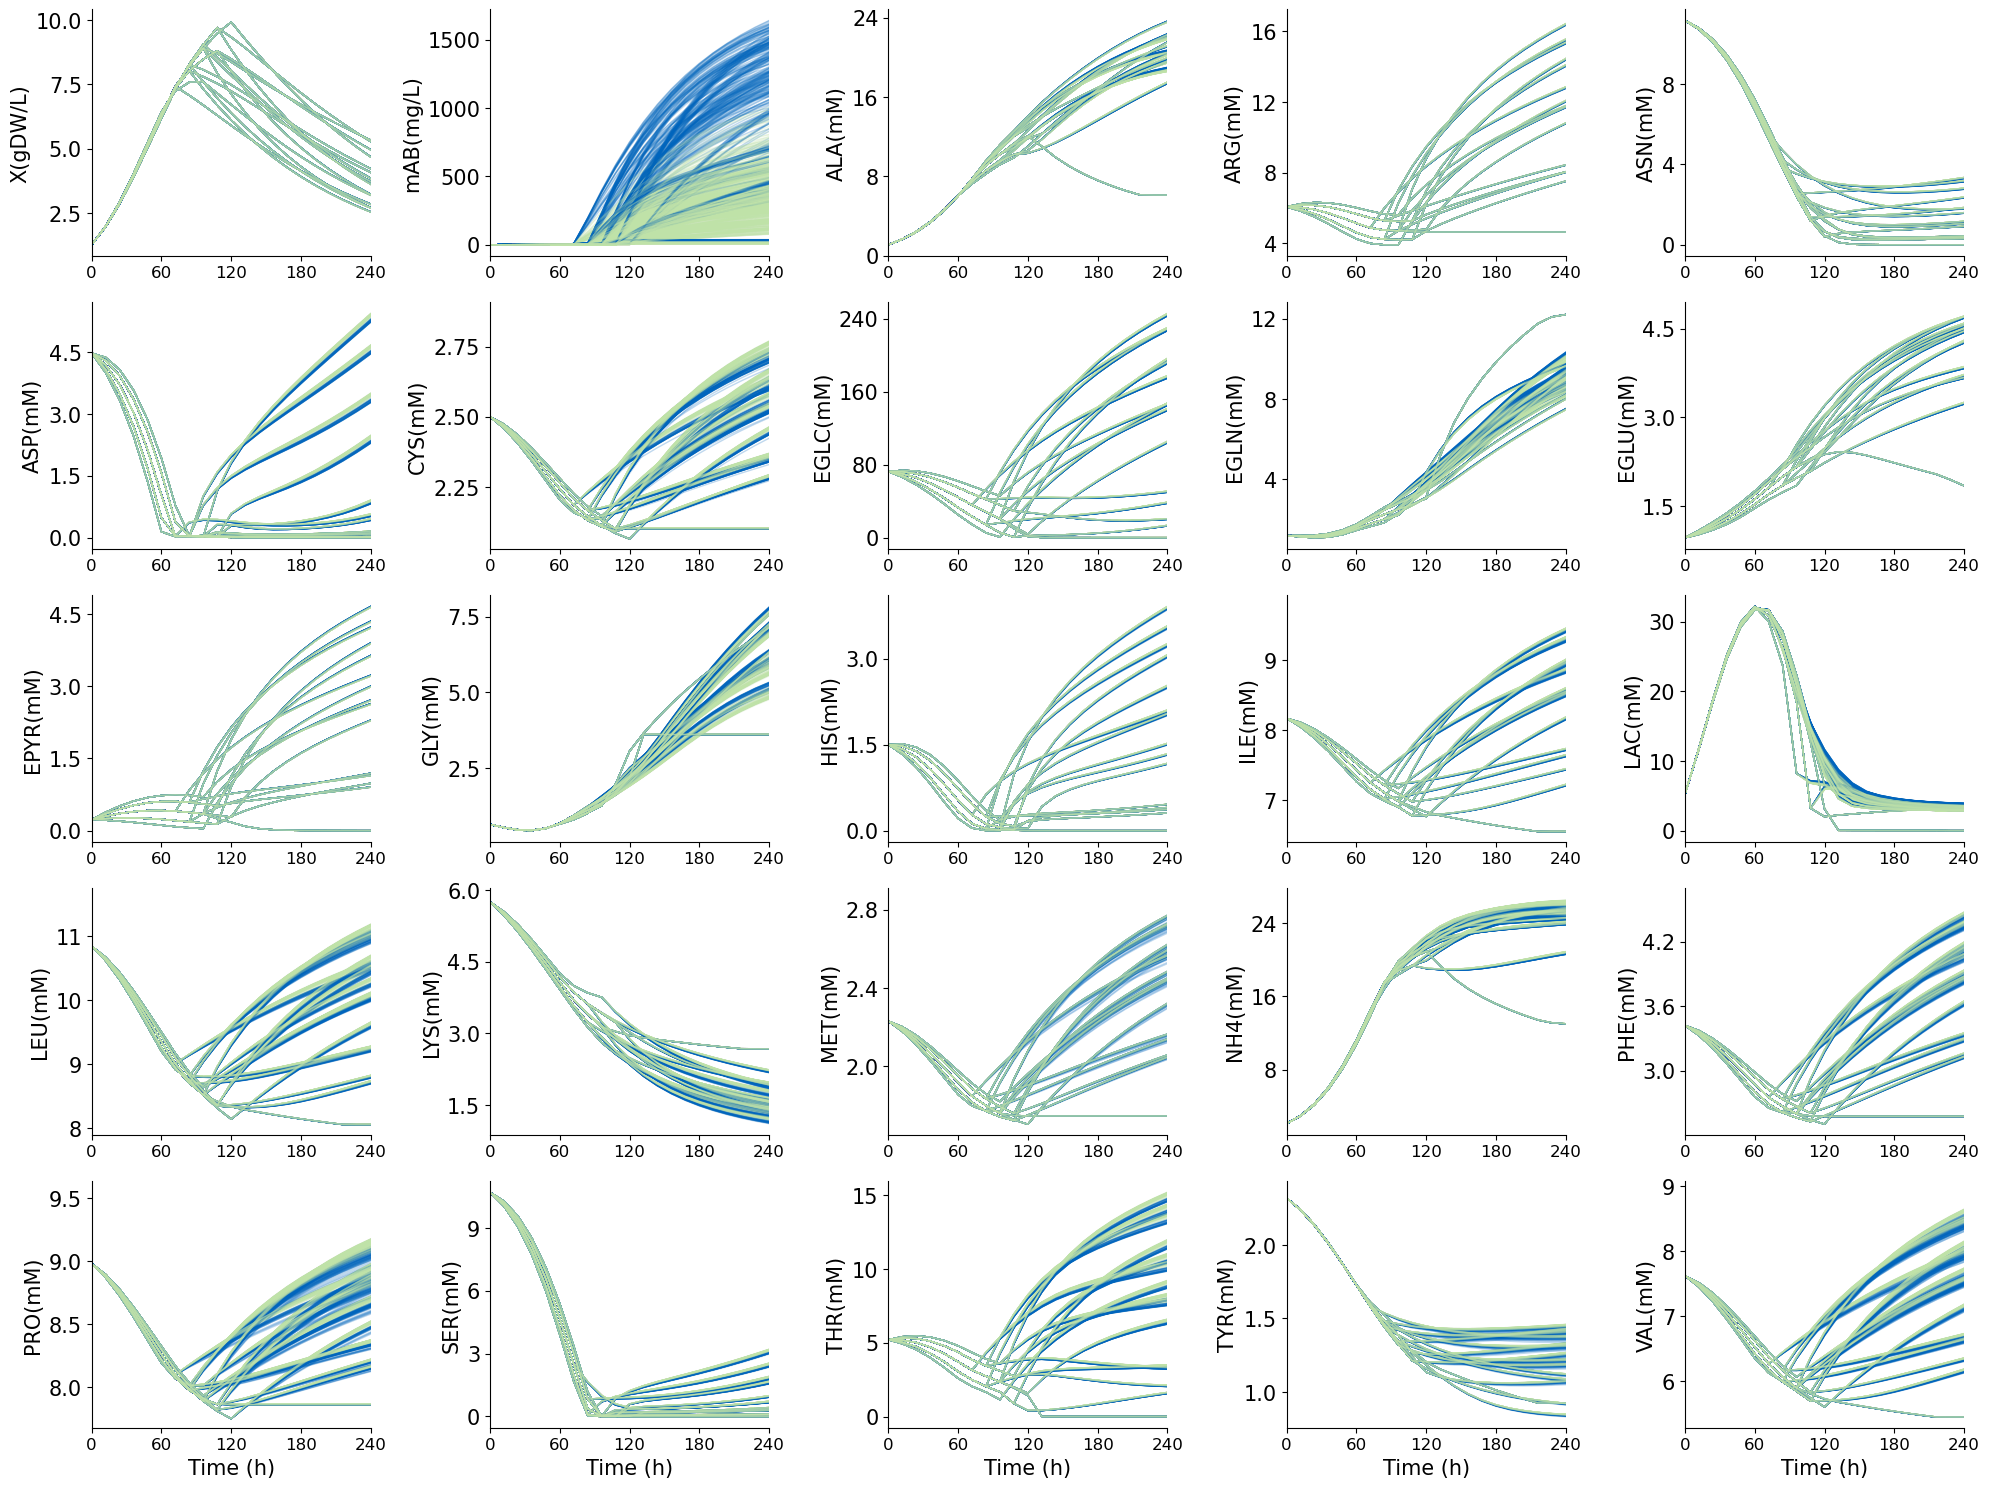

In [85]:
######################################### Cell 6D: Plot all species/batches/mAbs (single plot, clean style) ################################################

high_color = "#0065BD" # "#95D1E2"
low_color  = "#BFE2A8" 
from matplotlib.ticker import MaxNLocator
def plot_all_species_grid(all_mab_data, inputs_labels, n_cols=5):

    num_species = len(inputs_labels)
    n_rows = int(np.ceil(num_species / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axs = axs.flatten()

    bottom_row_idx_per_col = {}
    for s in range(num_species):
        col = s % n_cols
        row = s // n_cols
        bottom_row_idx_per_col[col] = max(bottom_row_idx_per_col.get(col, 0), row)

    #mab_idx = inputs_labels.index("mAB(mg/L)")

    #max value per species, across all mAbs and all batches, used as the y-axis top
    all_data_np = np.concatenate([data.numpy() for data in all_mab_data.values()], axis=0)
    species_max = all_data_np.max(axis=(0, 1))   # shape: (num_species,)

    for s in range(num_species):
        ax = axs[s]
        species_label = inputs_labels[s]

        #is_mab = (s == mab_idx)
        scale = 1 #1000 if is_mab else 1

        for mab_name, data in all_mab_data.items():

            productivity = get_mab_productivity(mab_name)
            color = high_color if productivity == "high" else low_color

            data_np = data.numpy()
            B, T, S = data_np.shape
            time_hours = [t * 12 for t in range(T)]

            for b in range(B):
                ax.plot(time_hours, data_np[b, :, s] / scale,
                        color=color, alpha=0.25, linewidth=1.0, zorder=1,
                        label="High productivity" if (s == 0 and mab_name == list(all_mab_data.keys())[0] and productivity == "high") else None)

        col = s % n_cols
        row = s // n_cols
        is_bottom_of_col = (row == bottom_row_idx_per_col[col])

        if is_bottom_of_col:
            ax.set_xlabel("Time (h)", fontsize=15)

        #ax.set_ylabel("mAb (g/L)" if is_mab else species_label, fontsize=15)
        ax.set_ylabel(species_label, fontsize=15)

        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        #top of y-axis set to the max value of this species across all mAbs/batches
        ax.set_ylim(top=(species_max[s] / scale) * 1.05)

        ax.tick_params(axis='y', labelsize=15, labelleft=True)
        ax.tick_params(axis='x', labelsize=12)
        ax.set_xticks([0, 60, 120, 180, 240])
        ax.set_xlim(0, 240)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for k in range(num_species, n_rows*n_cols):
        fig.delaxes(axs[k])

    #legend_elements = [
     #   Line2D([0], [0], color=high_color, lw=2, label='High productivity'),
     #   Line2D([0], [0], color=low_color, lw=2, label='Low productivity')
    #]
    #fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=13)

    plt.tight_layout()
    return fig

fig = plot_all_species_grid(all_mab_data, inputs_labels, n_cols=5)

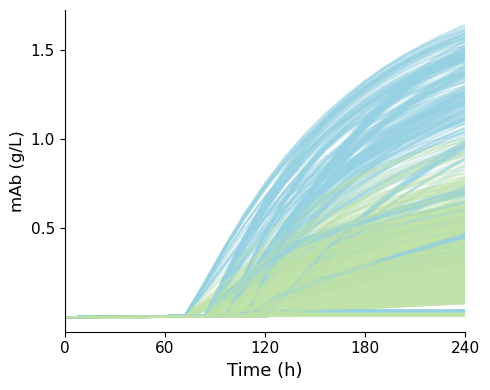

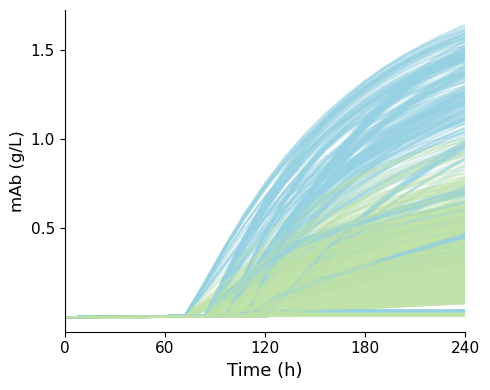

In [86]:
######################################### Cell 6E: Plot mAb only (single plot, g/L) ################################################

def plot_mab_only(all_mab_data, inputs_labels, mab_label="mAB(mg/L)", figsize=(5, 4)):

    mab_idx = inputs_labels.index(mab_label)

    fig, ax = plt.subplots(figsize=figsize)

    high_color = "#95D1E2" 
    low_color = "#BFE2A8"

    for mab_name, data in all_mab_data.items():

        productivity = get_mab_productivity(mab_name)
        color = high_color if productivity == "high" else low_color

        data_np = data.numpy()
        B, T, S = data_np.shape

        time_hours = [t * 12 for t in range(T)]

        for b in range(B):
            ax.plot(time_hours, data_np[b, :, mab_idx] / 1000,
                    color=color, alpha=0.35)

    ax.set_xlabel("Time (h)", fontsize=13)
    ax.set_ylabel("mAb (g/L)", fontsize=12)
    ax.set_yticks([0.5, 1.0, 1.5])
    ax.set_xticks([0, 60, 120, 180, 240])
    ax.tick_params(axis='both', labelsize=11)
    ax.set_xlim(0, 240) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #legend_elements = [Line2D([0], [0], color='red', lw=2, label='High productivity'), Line2D([0], [0], color='blue', lw=2, label='Low productivity') ]
    #ax.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    
    return fig

plot_mab_only(all_mab_data, inputs_labels)



### 7 - PCA Analysis

Teste Clean

In [ ]:
######################################### Cell 7A: Define PCA and retrieve data ################################################

#feed concentrations (0 for X and mAb)
feed_conc = {
    "mAB(mg/L)": 0.0, "X(gDW/L)": 0.0, "ALA(mM)": 0.0, "ARG(mM)": 29.71, "ASN(mM)": 15.0, "ASP(mM)": 25.0, "CYS(mM)": 3.32, "EGLC(mM)": 500,
    "EGLN(mM)": 5.0, "EGLU(mM)": 5.0, "EPYR(mM)": 39.67/4, "GLY(mM)": 0.0, "HIS(mM)": 11.73, "ILE(mM)": 46.96/4,
    "LAC(mM)": 0.0, "LEU(mM)": 27.71/2, "LYS(mM)": 1.02, "MET(mM)": 3.57, "NH4(mM)": 0.0, "PHE(mM)": 23.89/4, "PRO(mM)": 41.31/4,
    "SER(mM)": 72.97/3, "THR(mM)": 32.12, "TYR(mM)": 0.0, "VAL(mM)": 56.21/5}

#defining PCA - normalization and centering
class cPCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean = np.mean(X, axis=(0,1))
        self.std = np.std(X, axis=(0,1))

        #Xp = (X - self.mean) / self.std
        #print("Mean:", self.mean)
        #print("Std:", self.std) 
        #Xp = X  / self.std
        Xp = X
        
        cov = np.cov(Xp, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(cov)

        idx = np.argsort(eigvals)[::-1]

        #calculate loadings = coefficients = eigenvectors
        self.components = eigvecs[:, idx][:, :self.n_components]

        #calculate explained variance
        self.explained_variance = eigvals[idx][:self.n_components] / np.sum(eigvals)

    def transform(self, X):
        #self.mean = np.mean(X, axis=(0,1))
        #self.std = np.std(X, axis=(0,1))
        #return ((X - self.mean) / self.std) @ self.components
        #return ((X) / self.std) @ self.components
        return (X) @ self.components

    def inverse_transform(self, scores):
        #self.mean = np.mean(X, axis=(0,1))
        #self.std = np.std(X, axis=(0,1))
        #return (scores @ self.components.T) * self.std + self.mean
        #return (scores @ self.components.T) * self.std
        return scores @ self.components.T 

#calculate reacted amounts from excel files
def reconstruct_reacted_amount(df, species):

    t = df["t(h)"].values #h
    V = df["V(L)"].values #L
    C = df[species].values #mM (mmol/L) except X (gDW/L) and mAb ((mg/L)

    #calculate mass total
    mass = C * V #mmol/L * L = mmol
    F = df["feed_rate"].values #L/h
    Cfeed = feed_conc[species] #mmol/L
    dt = np.diff(t) #h

    #calculate mass added
    feed_added = np.zeros_like(t) #mmol
    for i in range(1, len(t)):
        feed_added[i] = (feed_added[i-1] + F[i-1] * Cfeed  * dt[i-1])
             #   mmol =          mmol    + (L/h   * mmol/L *  h )  

    #calculate reacted amounts
    RA = (mass - mass[0] - feed_added) #mmol
    return RA

#map RA to species name
species = ['X(gDW/L)', 'mAB(mg/L)', 'ALA(mM)', 'ARG(mM)', 'ASN(mM)',
                    'ASP(mM)', 'CYS(mM)', 'EGLC(mM)', 'EGLN(mM)',
                    'EGLU(mM)', 'EPYR(mM)', 'GLY(mM)', 'HIS(mM)',
                    'ILE(mM)', 'LAC(mM)', 'LEU(mM)', 'LYS(mM)',
                    'MET(mM)', 'NH4(mM)', 'PHE(mM)', 'PRO(mM)',
                    'SER(mM)', 'THR(mM)', 'TYR(mM)', 'VAL(mM)']

#calculate reacted amounts
def load_batches(mab, doe_list):
    mab_folder = find_mab_folder(mab)
    filenames = find_doe_files(mab, mab_folder, doe_list)

    RA_batches = []
    for filename in filenames:
        df = pd.read_csv(filename)
        RA = np.column_stack([
            reconstruct_reacted_amount(df, s)
            for s in species])

        RA_batches.append(RA)
    return np.array(RA_batches)   # (15,21,25)

def get_final_mab_concentration(df):
    return df["mAB(mg/L)"].values[-1]

In [ ]:
######################################### Cell 7B: Run PCA and save results ################################################

pca_components_results = []
all_loadings_norm = {}
all_loadings_denorm = {}
all_loadings_pinv = {}
all_loadings_denorm_norm = {}
pca_stats = {}

n_save_components = 25

mabnames_list = ['Adalimumab']

for mab in mabnames_list:

    #extract all 15 batches
    mab_folder = find_mab_folder(mab)
    filenames_path = find_doe_files(mab, mab_folder, DoE_framework)

    #initialize RA, Cc and final mAb values
    X_batches = []
    final_mab_values = []

    for filename in filenames_path:

        df = pd.read_csv(filename)

        if RA: #extract reacted amounts (RA)        
            X = np.column_stack([reconstruct_reacted_amount(df, s) for s in species])
        else:          #extract concentrations (Cs)        
            X = df[species].values
            
        X_batches.append(X)
        final_mab_values.append(df["mAB(mg/L)"].values[-1]) #extract final mAb values

############################## Build data, mean and std arrays without normalization #########################3

    X_batches = np.array(X_batches)  # (15, time, species)

    rows = []
    for batch_idx in range(X_batches.shape[0]):
        for t_idx in range(X_batches.shape[1]):
            row = {"batch": batch_idx, "time_idx": t_idx}
            for i, sp in enumerate(species):
                row[sp] = X_batches[batch_idx, t_idx, i]
            rows.append(row)
    X_batches_df = pd.DataFrame(rows)
    X_batches_path = os.path.join(LOCAL_OUTPUT_DIR, "PCA_input_batches_RA.xlsx")
    X_batches_df.to_excel(X_batches_path, index=False)
    print(f"Saved PCA input data to {X_batches_path}")

    #print(X_batches)
    final_mab_values = np.array(final_mab_values)

    #sort by mAb concentration (low → high)
    sorted_idx = np.argsort(final_mab_values)
    X_batches = X_batches[sorted_idx]

    #drop highest mAb batch (test set)
    X_batches_train = X_batches[:-1] #(batches, timepoints, species) = dimention 0, 1, 2
    X_batches_test = X_batches[-1] #(batches, timepoints, species) = dimention 0, 1, 2

    if X_batches_train.any() == 0:
        print("state already contains NaN")
    
    #extract max of each species 8normalization is NOT performed
    X_batches_train_max = np.max(abs(X_batches_train), axis=(0,1)) #collapse dimentions 0 (batches) and 1 (timepoinst), leaving 2 (species)
    X_batches_train_norm = X_batches_train / X_batches_train_max

    np.set_printoptions(threshold=np.inf, linewidth=np.inf)
    if debug:
        print("X_batches_train")
        print(X_batches_train[0, :2])
        print(X_batches_train.shape)
        print("X_batches_train_max")
        print(X_batches_train_max[:2])
        print(X_batches_train_max.shape)

    if debug:
        print("X_batches_train:")
        print(X_batches_train)
        print(X_batches_train.shape)
        print("X_batches_train_max:")
        print(X_batches_train_max)
        print(X_batches_train_max.shape)
        print("X_batches_train_norm:")
        print(X_batches_train_norm)
        print(X_batches_train_norm.shape)

    X_batches_test_norm = X_batches_test / X_batches_train_max

    mean_X = np.mean(X_batches_train_norm, axis=(0,1)) #X_batches_train_norm.mean(axis=(0,1))
    std_X = np.std(X_batches_train_norm, axis=(0,1))

    #flatten for PCA
    X = X_batches_train_norm
    X = X.reshape(-1, X.shape[-1])

    X_test = X_batches_test_norm
    X_test = X_test.reshape(-1, X_test.shape[-1])
    
    ###################################  PCA  ##########################################################
    np.set_printoptions(threshold=np.inf, linewidth=np.inf)
    if debug:
        print("X")
        print(X[:26])
        print(X.shape)

    #the PCA is done with 25 PCS
    pca = cPCA(n_components=len(species)) #n_save_components)
    pca.fit(X)

    components = np.array(pca.components, copy=True)

    #calculate explained variance  
    explained_variance = pca.explained_variance * 100
    cum_sum = np.cumsum(explained_variance)

    d = np.argmax(cum_sum >= 95.0) + 1

    if d > n_save_components:
        print(f"WARNING: PC components saved is less than 95% explained variance!")

    print(f"For {mab}, 95% variance at {d} PCs")

    ############################ CHANGE NUMBER OF COMPONENTS SAVED HERE ############################
    n_save_components = 25
    n_pc = max(n_save_components, d)
    print(n_pc)
    
    #save loading matrix based on previous number
    loadings_norm = pd.DataFrame(data=components[:, :n_pc], index=species, columns=[f"PC{i+1}" for i in range(n_pc)])
    all_loadings_norm[mab] = loadings_norm

    pca_stats[mab] = {
        "std": pca.std,
        "mean": pca.mean,
        "ra_max": X_batches_train_max}
    
    #print(X_batches_train_max.shape)
    #print(X_batches_train_max.T)
    #print(loadings.shape)
    
    loadings_denorm = loadings_norm * X_batches_train_max[:,None]

    if debug:
        print("loadings_norm:")
        print(loadings_norm)
        print("X_batches_train_max:")
        print(X_batches_train_max)
        
    #print(loadings_denorm)
    #all_loadings_denorm[mab] = loadings_denorm
    loadings_denorm_max = np.max(abs(loadings_denorm), axis=0)
    loadings_denorm_norm = loadings_denorm / loadings_denorm_max.to_numpy()

    a = loadings_norm
    pa = pd.DataFrame(np.linalg.pinv(loadings_norm))

    if debug:
        print("loadings_denorm:")
        print(loadings_denorm)
        print("loadings_denorm_max:")
        print(loadings_denorm_max.to_numpy())
        print("loadings_denorm_norm:")
        print(loadings_denorm_norm)

    all_loadings_denorm[mab] = loadings_denorm_norm
    
    loadings_denorm_pinv = pd.DataFrame(np.linalg.pinv(loadings_denorm_norm))
    #print(loadings_denorm_pinv)

    all_loadings_pinv[mab] = loadings_denorm_pinv

    loadings_denorm_pinv_2 = np.linalg.pinv(loadings_denorm)
    I = loadings_denorm_pinv_2 @ loadings_denorm
    
    for i in range(n_pc):
        row = [mab, f"PC{i+1}"] + pca.components[:, i].tolist()
        pca_components_results.append(row)

######################################### save results ############################################

loadings_df = pd.concat(all_loadings_norm, axis=1)
loadings_df.columns.names = ["mAb", "PC"]

loadings_denorm_df = pd.concat(all_loadings_denorm, axis=1)
loadings_denorm_df.columns.names = ["mAb", "PC"]

loadings_pinv_df = pd.concat(all_loadings_pinv, axis=1)
loadings_pinv_df.columns.names = ["mAb", "PC"]

#print(loadings_df)
std_df = pd.DataFrame({mab: pca_stats[mab]["std"] for mab in pca_stats}, index=species)
mean_df = pd.DataFrame({mab: pca_stats[mab]["mean"] for mab in pca_stats}, index=species)
ra_max_df = pd.DataFrame({mab: pca_stats[mab]["ra_max"] for mab in pca_stats}, index=species)

loadings_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_loadings_norm_{n_pc}.xlsx")
loadings_denorm_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_loadings_denorm_{n_pc}.xlsx")
loadings_pinv_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_loadings_pinv_{n_pc}.xlsx")

ra_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_{n_pc}_LG.xlsx")
std_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_std_{n_pc}_LG.xlsx")
mean_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_mean_{n_pc}_LG.xlsx")
ra_max_path = os.path.join(LOCAL_OUTPUT_DIR, f"PCA_max_{n_pc}_LG.xlsx")

loadings_df.to_excel(loadings_path)
loadings_denorm_df.to_excel(loadings_denorm_path)
loadings_pinv_df.to_excel(loadings_pinv_path)
ra_max_df.to_excel(ra_max_path)

#print(f"loadings_df saved to {loadings_path}")
#print(f"loadings_denorm_df saved to {loadings_denorm_path}")
#print(f"loadings_pinv_df saved to {loadings_pinv_path}")

#scores of every sample
scores = pca.transform(X)              # (N_samples, 25)

scores_test = pca.transform(X_test)     # (N_samples, 25)

#keep only first n_pc PCs
scores_n_pc = np.zeros_like(scores)
scores_n_pc[:, :n_pc] = scores[:, :n_pc]

scores_test_n_pc = np.zeros_like(scores_test)
scores_test_n_pc[:, :n_pc] = scores_test[:, :n_pc]

#reconstruct normalized data
X_rec_norm = pca.inverse_transform(scores_n_pc)

X_rec_test_norm = pca.inverse_transform(scores_test_n_pc)

#undo normalization
#X_rec = X_rec_norm * std_X + mean_X #* X_batches_train_max
X_rec = X_rec_norm * X_batches_train_max
X_rec_test = X_rec_test_norm * X_batches_train_max

X_norm = X #* X_batches_train_max
X_test_norm = X_test #* X_batches_train_max

#original data (not normalized)
X_true = X * X_batches_train_max
X_test_true = X_test * X_batches_train_max
#X_true = X * std_X + mean_X #X_batches_train.reshape(-1, X_batches_train.shape[-1])

#print("X_rec_norm:", X_rec_norm)
#print("X:", X_rec)
X_true_max = np.max(np.abs(X_true), axis=(0))  #get the maximum absolute value for each species
relative_error = np.abs(X_rec - X_true) / X_true_max 

X_test_max = np.max(np.abs(X_test_true), axis=(0))  #get the maximum absolute value for each species
relative_error_test = np.abs(X_rec_test - X_test_true) / X_test_max

species_error = relative_error.mean(axis=0)
species_error_test = relative_error_test.mean(axis=0)

for s, e in zip(species, species_error):
    print(f"{s:12s}: {100*e:.6f}%")

for s, e in zip(species, species_error_test):
    print(f"{s:12s}: {100*e:.6f}%")

overall_error = relative_error.mean()
overall_error_test = relative_error_test.mean()

print(f"Overall mean relative error = {100*overall_error:.4f}%")
print(f"Overall mean relative error (test) = {100*overall_error_test:.4f}%")

plt.figure(figsize=(7,7))
plt.scatter(X_rec_norm, X_norm, s=8, alpha=0.40, color='blue', label='Training')
plt.scatter(X_rec_test_norm, X_test_norm, s=8, alpha=0.40, color='red', label='Test')
plt.xlabel("Measured")
plt.ylabel("Predicted")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close()

print("r2 score:", r2_score(X_rec, X_true))
print("r2 score (test):", r2_score(X_rec_test, X_test_true))

Saved PCA input data to C:\Users\SBEGroup\Desktop\ESACT2026_Hybrid_Modelling\Excel\PCA_input_batches_RA.xlsx
For Adalimumab, 95% variance at 3 PCs
25
X(gDW/L)    : 0.000000%
mAB(mg/L)   : 0.000000%
ALA(mM)     : 0.000000%
ARG(mM)     : 0.000000%
ASN(mM)     : 0.000000%
ASP(mM)     : 0.000000%
CYS(mM)     : 0.000000%
EGLC(mM)    : 0.000000%
EGLN(mM)    : 0.000000%
EGLU(mM)    : 0.000000%
EPYR(mM)    : 0.000000%
GLY(mM)     : 0.000000%
HIS(mM)     : 0.000000%
ILE(mM)     : 0.000000%
LAC(mM)     : 0.000000%
LEU(mM)     : 0.000000%
LYS(mM)     : 0.000000%
MET(mM)     : 0.000000%
NH4(mM)     : 0.000000%
PHE(mM)     : 0.000000%
PRO(mM)     : 0.000000%
SER(mM)     : 0.000000%
THR(mM)     : 0.000000%
TYR(mM)     : 0.000000%
VAL(mM)     : 0.000000%
X(gDW/L)    : 0.000000%
mAB(mg/L)   : 0.000000%
ALA(mM)     : 0.000000%
ARG(mM)     : 0.000000%
ASN(mM)     : 0.000000%
ASP(mM)     : 0.000000%
CYS(mM)     : 0.000000%
EGLC(mM)    : 0.000000%
EGLN(mM)    : 0.000000%
EGLU(mM)    : 0.000000%
EPYR(mM)  

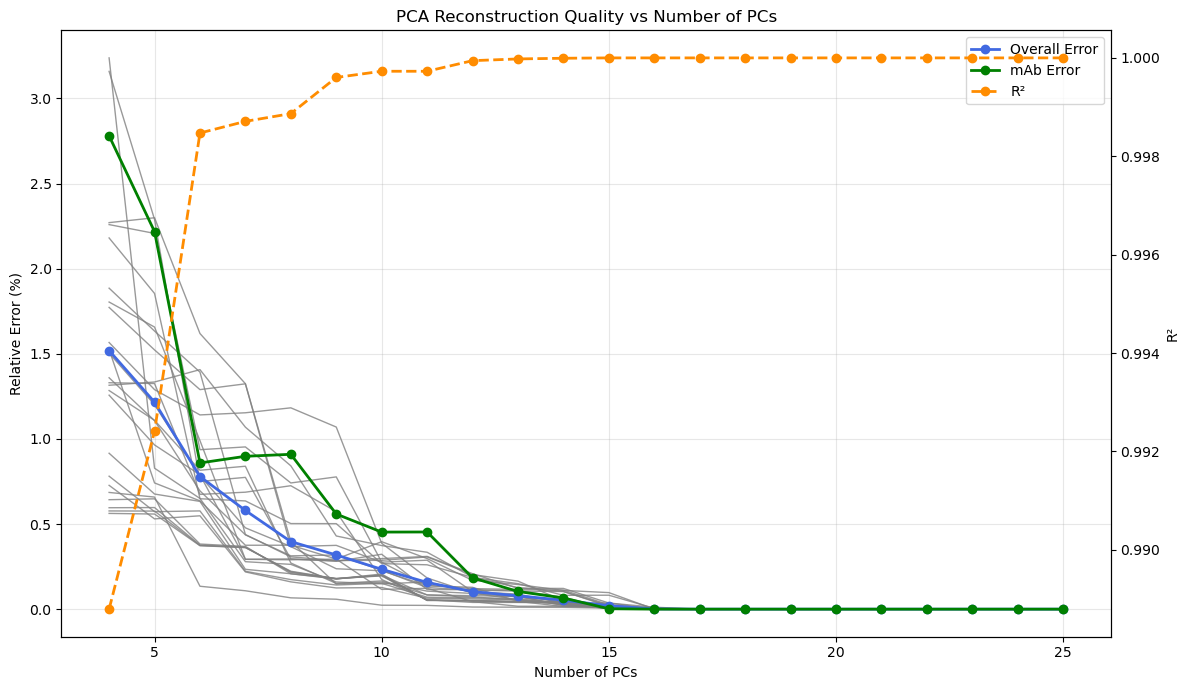

In [89]:
################################ PCA performance vs number of PCs ################################

# PCA already fitted above:
# pca.fit(X)

scores = pca.transform(X)

pc_range = np.arange(4, 26)

overall_errors = []
mab_errors = []
r2_values = []

all_species_errors = []

mab_idx = species.index("mAB(mg/L)")

for n_pc in pc_range:

    # keep only first n_pc PCs
    scores_n_pc = np.zeros_like(scores)
    scores_n_pc[:, :n_pc] = scores[:, :n_pc]

    # reconstruct normalized data
    X_rec_norm = pca.inverse_transform(scores_n_pc)

    # back to original units
    X_rec = X_rec_norm * X_batches_train_max
    X_true = X * X_batches_train_max

    # relative error
    X_true_max = np.max(np.abs(X_true), axis=0)

    relative_error = np.abs(X_rec - X_true) / X_true_max 

    species_error = relative_error.mean(axis=0)

    overall_error = relative_error.mean()

    overall_errors.append(100 * overall_error)
    mab_errors.append(100 * species_error[mab_idx])

    r2_values.append(r2_score(X_true.flatten(), X_rec.flatten()))

    all_species_errors.append(100 * species_error)

all_species_errors = np.array(all_species_errors)

################################ Plot ################################

fig, ax1 = plt.subplots(figsize=(12,7))

# species
for i, sp in enumerate(species):

    if sp == "mAB(mg/L)":
        continue

    ax1.plot(pc_range, all_species_errors[:, i], color='gray', linewidth=1, alpha=0.8)

# highlighted curves
ax1.plot(pc_range, overall_errors, linewidth=2,color='royalblue', marker='o', label='Overall Error')

ax1.plot(pc_range, mab_errors, linewidth=2, color='green', marker='o', label='mAb Error')

ax1.set_xlabel("Number of PCs")
ax1.set_ylabel("Relative Error (%)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(pc_range, r2_values, linestyle='--', linewidth=2, color='darkorange', marker='o', label='R²')

ax2.set_ylabel("R²")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("PCA Reconstruction Quality vs Number of PCs")
plt.tight_layout()
plt.show()